# Convertible note offerings — covered call (v3)

Thesis: convertible note offerings generate mechanical stock pressure from arbitrage hedge flows, and the options on these names stay rich after issuance. Trade: long stock + short ATM call (every listed expiry 14–63 DTE) at the close `ENTRY_DELAY` sessions after the first tradable close following EDGAR acceptance, held 21 sessions.

**v3 changes the hypothesis not at all; it changes what counts as evidence.** The headline number is now event − placebo, because a covered call earns its risk premium on ordinary days too. Every parameter is chosen by walk-forward on TRAIN, written to `frozen_config.json` before VALIDATE is looked at, and the Sharpe interval is corrected for the fact that positions overlap. Section 8 lists every change and the bias it removes.


## 1 · Imports + API client (cached, rate-limit-aware)


In [28]:
import os, json, time, hashlib, re, tempfile
from dataclasses import dataclass, field
from pathlib import Path
from getpass import getpass
from statistics import NormalDist

import numpy as np
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pandas.tseries.holiday import (AbstractHolidayCalendar, Holiday, nearest_workday, USMartinLutherKingJr,
                                    USPresidentsDay, GoodFriday, USMemorialDay, USLaborDay, USThanksgivingDay)
from pandas.tseries.offsets import CustomBusinessDay

BASE_URL = "https://api.massive.com"


def load_api_key(name: str = "MASSIVE_API_KEY") -> str:
    """Environment first, then a `.env` file beside the notebook, then a prompt. Never paste a key into a cell."""
    key = (os.environ.get(name) or "").strip()
    env_file = Path(".env")
    if not key and env_file.exists():
        for line in env_file.read_text().splitlines():
            if line.strip().startswith(f"{name}="):
                key = line.split("=", 1)[1].strip().strip('"').strip("'")
    if not key:
        key = getpass(f"{name} (https://massive.com/dashboard/keys): ").strip()
    return key


API_KEY = load_api_key()
SESSION = requests.Session()
SESSION.headers["Authorization"] = f"Bearer {API_KEY}"
# Pricing runs PRICE_WORKERS events at once, so the connection pool must be bigger than the
# default 10 or every worker blocks on a fresh TCP+TLS handshake.
SESSION.mount("https://", requests.adapters.HTTPAdapter(pool_maxsize=32, pool_connections=32))

CACHE_DIR = Path(".massive_cache")
CACHE_DIR.mkdir(exist_ok=True)


def api_get(path_or_url: str, params: dict | None = None) -> dict:
    """GET one page from the Massive REST API. Cached on disk by the full URL, so reruns are free."""
    url = path_or_url if path_or_url.startswith("http") else BASE_URL + path_or_url
    full_url = requests.Request("GET", url, params=params).prepare().url
    cache_file = CACHE_DIR / (hashlib.sha1(full_url.encode()).hexdigest() + ".json")
    if cache_file.exists():
        try:
            txt = cache_file.read_text()
            if txt.strip():
                return json.loads(txt)
        except (json.JSONDecodeError, ValueError):
            cache_file.unlink(missing_ok=True)
    for attempt in range(10):
        resp = SESSION.get(full_url, timeout=60)
        if resp.status_code in (429, 500, 502, 503, 504):
            retry_after = resp.headers.get("Retry-After", "")
            time.sleep(float(retry_after) if retry_after.isdigit() else min(2 ** attempt, 20))
            continue
        break
    resp.raise_for_status()
    try:
        payload = resp.json()
    except ValueError:
        print(f"WARNING: non-JSON response from {url} (status {resp.status_code})")
        payload = {}
    fd, tmp_name = tempfile.mkstemp(dir=CACHE_DIR, prefix=cache_file.stem + ".", suffix=".tmp")
    with os.fdopen(fd, "w") as fh:                       # unique per call, so the PRICE_WORKERS threads
        fh.write(json.dumps(payload))                    # and a second run never share one temp file
    for attempt in range(8):                             # Windows holds a just-written file open for a
        try:                                             # moment (indexer, or a thread reading this very
            os.replace(tmp_name, cache_file)             # page): retry rather than drop the cache write
            break
        except PermissionError:
            if attempt == 7:
                Path(tmp_name).unlink(missing_ok=True)   # payload is already in hand; the cache is only
                break                                    # an optimization, so never fail the run over it
            time.sleep(0.05 * (attempt + 1))
    return payload


def api_get_all(path: str, params: dict | None = None, max_pages: int = 500) -> list[dict]:
    """Follow `next_url` pagination and return every result row."""
    payload = api_get(path, params)
    rows = list(payload.get("results") or [])
    pages = 1
    while payload.get("next_url") and pages < max_pages:
        payload = api_get(payload["next_url"])
        rows.extend(payload.get("results") or [])
        pages += 1
    return rows


print(f"API key loaded (ends {API_KEY[-4:]}); cache at {CACHE_DIR.resolve()}")


API key loaded (ends bDot); cache at C:\Users\yash2\Desktop\OpenSource\massiveandslightlypassive\.massive_cache


## 2 · Trading calendar (no stock feed in this challenge)


In [29]:
class NYSEHolidays(AbstractHolidayCalendar):
    """NYSE full-day closures. Differs from the federal calendar: Good Friday closed, Columbus and
    Veterans Day open, no observance when New Year's Day falls on a Saturday."""
    rules = [
        Holiday("New Year's Day", month=1, day=1,
                observance=lambda d: d + pd.Timedelta(days=1) if d.weekday() == 6 else d),
        USMartinLutherKingJr, USPresidentsDay, GoodFriday, USMemorialDay,
        Holiday("Juneteenth", month=6, day=19, start_date="2022-01-01", observance=nearest_workday),
        Holiday("Independence Day", month=7, day=4, observance=nearest_workday),
        USLaborDay, USThanksgivingDay,
        Holiday("Christmas Day", month=12, day=25, observance=nearest_workday),
        Holiday("National day of mourning, President Carter", year=2025, month=1, day=9),
    ]


def trading_sessions(start, end) -> pd.DatetimeIndex:
    holidays = NYSEHolidays().holidays(pd.Timestamp(start) - pd.Timedelta(days=7), pd.Timestamp(end) + pd.Timedelta(days=7))
    return pd.bdate_range(start, end, freq=CustomBusinessDay(holidays=holidays))


CAL = trading_sessions("2021-06-01", "2027-12-31")
TODAY = pd.Timestamp.today().normalize()
LAST_SESSION = CAL[CAL.searchsorted(TODAY, side="right") - 1]


def session_on_or_after(day) -> pd.Timestamp:
    return CAL[CAL.searchsorted(pd.Timestamp(day), side="left")]


def session_before(day) -> pd.Timestamp:
    idx = CAL.searchsorted(pd.Timestamp(day), side="left") - 1
    return CAL[max(idx, 0)]


def sessions_between(a, b) -> int:
    """Number of sessions strictly after `a` up to and including `b`."""
    return int(CAL.searchsorted(pd.Timestamp(b), side="right") - CAL.searchsorted(pd.Timestamp(a), side="right"))


print(f"{len(CAL)} sessions in the calendar; last completed session {LAST_SESSION.date()}. "
      f"Sessions per year: " + ", ".join(f"{y}: {((CAL.year == y)).sum()}" for y in range(2022, 2027)))

1655 sessions in the calendar; last completed session 2026-10-02. Sessions per year: 2022: 251, 2023: 250, 2024: 252, 2025: 250, 2026: 251


## 3 · Configuration — convertible note offering, covered call


In [30]:
# ---- Convertible note offering strategy ----------------------------------------------------
# Item codes for convertible note offerings in 8-Ks
CONVERTIBLE_ITEM_CODES = ["1.01", "2.03"]

# Keywords to identify convertible note offerings in supporting_text
CONVERTIBLE_KEYWORDS = [
    "convertible senior notes",
    "convertible notes",
    "convertible note offering",
    "pricing of convertible",
    "aggregate principal amount of convertible",
    "convertible subordinated notes",
    "convertible unsecured notes",
]

# Throughput ---------------------------------------------------------------------------------
PRICE_WORKERS = 16               # events priced concurrently. Every step is an HTTP call, so this
                                  # loop is I/O bound; 16 workers measures ~5x the serial pace with no
                                  # 429s.
N_PLACEBO = 1500                 # placebo sessions, drawn ticker-weighted from the same pool as the
                                  # events. Each yields ~2.3 structures (every expiry in the band).

# Filters -----------------------------------------------------------------------------------
# Two repurchase screens. The loose one is a REPORTED FLAG only: as a drop it matched 36% of
# large-cap convert filings (4 of 11 candidates) that had no concurrent repurchase at all.
# Only CONCURRENT_REPURCHASE_PHRASES may drop an event -- 0 hits on those same 11 candidates.
REPURCHASE_PHRASES = ["repurchase", "buyback", "tender offer"]
CONCURRENT_REPURCHASE_PHRASES = [
    "concurrent open market repurchase", "concurrently", "share repurchase program",
    "open market repurchase program", "tender offer for", "issuer repurchase",
]
NO_CONCURRENT_REPURCHASE = True
CAPPED_CALL_SPLIT = True

# Trade parameters --------------------------------------------------------------------------
CALL_MIN_DTE = 14                 # minimum days to expiry. Widened from 28: mid/small-cap convert
                                  # issuers list monthly (~35-45 DTE) or quarterly expiries, so the
                                  # 14-28 band contained no listed expiry for most of them.
                                  # 400-event sample: 40.5% priced at 14-28, 60.0% at 14-63.
CALL_MAX_DTE = 63                 # maximum days to expiry
CALL_TARGET_DTE = 30              # target days to expiry -- ordering only; every expiry in band trades
                                  # (mean 2.9 expiries per event inside 14-63 DTE)
TRADE_ALL_EXPIRIES = True         # one structure per expiry in the band, not just the nearest
CALL_STRIKE_ATR_MULT = 0.0        # short strike at ATM (0 ATR above spot)
ATR_PERIOD = 14                   # ATR lookback period
MAX_EVENTS = None                 # set to an int for a smoke test; None = all events
MAX_STALE_SESSIONS = 3            # a leg/stock mark may be at most this many sessions old

# Universe -----------------------------------------------------------------------------------
TOP_500 = """
AAPL ABBV ABT ACN ADBE AIG AMD AMGN AMT AMZN AVGO AXP BA BAC BK BKNG BLK BMY BRK.B C
CAT CHTR CL CMCSA COF COP COST CRM CSCO CVS CVX DE DHR DIS DUK EMR FDX GD GE GILD
GM GOOGL GS HD HON IBM INTC INTU ISRG JNJ JPM KO LIN LLY LMT LOW MA MCD MDLZ MDT
MET META MMM MO MRK MS MSFT NEE NFLX NKE NOW NVDA ORCL PEP PFE PG PLTR PM PYPL QCOM
RTX SBUX SCHW SO T TGT TMO TMUS TSLA TXN UBER UNH UNP UPS USB V VZ WFC WMT XOM
ABMD ADSK ALGN ANET APH ATO BAX BDX BIO BMRN CAG CDNS CERN CHD CINF CLX CMG
CNC COO CTSH DAL DGX DHI DLR DOW DVN EBAY EW EXC FAST FIS FISV FLT GEHC GIB GLW
GPC GRMN HCA HES HPQ HUBB HUM IDXX ILMN INFO IP IRM JCI KDP KHC KMI KR LBTYA
LRCX LULU MAR MCHP MMC MNST MPC MRVL MSS MSCI NDAQ NEM NTRS OKE OMC PAYX PDD
PGR PH PNC POOL PSX PTC QVCC RCL REGN ROK RSG SBAC SHW SLB SNA SPGI STT SWKS
TCOM TDG TEL TFX TJX TPR TTWO UAL VRT VTR WBA WBD WHR WRK WY XEL YUM ZBH ZBRA
""".split()
assert len(TOP_500) == 208 and len(set(TOP_500)) == 208
UNIVERSE = None                 # EVERY ticker in the disclosures. Measured 2023-25: 1,069 convertible
                               # events across 513 tickers, of which only 7 tickers / 11 events sit in
                               # TOP_500 -- that 208-name list was ~99% of the sampling loss. Set to
                               # TOP_500 to return to the large-cap-only subset.

# Fixed horizons -----------------------------------------------------------------------------
HORIZONS = [1, 2, 3, 5, 10, 21, 42, 63]   # sessions after entry. Fixed for every team: report all
                                          # eight, then expiry. Do not cherry-pick the good one.

# Expiry buckets -----------------------------------------------------------------------------
EXPIRY_BUCKETS = {"1m": (21, 45), "2m": (46, 80), "3-6m": (90, 180)}   # calendar DTE from entry
BASELINE_BUCKET = "1m"           # the headline bucket. OptionsPlaybook's own covered-call timing rule
                                  # is 30-45 DTE, and it is the only prescribed bucket fully inside
                                  # the 14-63 DTE trade band, so it is the one every other table uses
                                  # unless it says otherwise.

# Stretch toggles -----------------------------------------------------------------------------
RUN_PLACEBO = True
PLACEBO_GAP_DAYS = 30
FETCH_ACCEPTANCE_TIMES = True
SEC_USER_AGENT = "GatorQuantHacks team-name your@email.edu"

assert CALL_MIN_DTE < CALL_MAX_DTE
assert len(HORIZONS) == 8


## 4 · Convertible note event fetch


In [31]:
def normalize_ticker(t) -> str | None:
    """Filings write share classes as BRK/B or BRK.B; Massive's options use BRK.B as the underlying."""
    if not isinstance(t, str) or not t.strip():
        return None
    return t.strip().upper().replace("/", ".")


def fetch_convertible_offerings(start: str, end: str, universe: list[str]) -> pd.DataFrame:
    """Fetch 8-K disclosures for the date range.

    `item_codes` is ignored by this endpoint -- 1.01 and 2.03 each returned the identical 231,188
    rows, then 52,164 for the OOS window -- so the old loop downloaded every page twice and then
    deduped the copies back to one. That doubled cold-start time and the on-disk cache for nothing.
    One query is issued instead; the convertible-note selection is the keyword filter's job.
    """
    rows = api_get_all("/stocks/filings/8-K/vX/disclosures", {
        "item_codes": CONVERTIBLE_ITEM_CODES[0],
        "filing_date.gte": start,
        "filing_date.lte": end,
        "limit": 1000,
        "sort": "filing_date.asc",
    })
    df = pd.DataFrame(rows)
    print(f"  {len(df):,} 8-K disclosures, {start}..{end} (one page set; item_codes is not a server filter)")
    if df.empty:
        return df
    if "item_codes" in df.columns:
        want = set(CONVERTIBLE_ITEM_CODES)
        codes = df["item_codes"].fillna("").astype(str)
        n_hit = int(codes.apply(lambda s: bool(want & set(re.findall(r"\d+\.\d+", s)))).sum())
        print(f"  {n_hit:,} of those actually carry item {'/'.join(CONVERTIBLE_ITEM_CODES)}")
    df["filing_date"] = pd.to_datetime(df["filing_date"])
    return df


def is_convertible_offering(row) -> bool:
    """Heuristic: check supporting_text for convertible note keywords."""
    text = str(row.get("supporting_text", "")).lower()
    return any(kw in text for kw in CONVERTIBLE_KEYWORDS)


def keyword_mask(text: pd.Series, keywords: list[str]) -> pd.Series:
    """Vectorized substring screen (~100x faster than row-wise apply on 200k+ rows)."""
    lowered = text.fillna("").str.lower()
    hit = pd.Series(False, index=text.index)
    for kw in keywords:
        hit |= lowered.str.contains(kw.lower(), regex=False)
    return hit


def has_concurrent_repurchase(row) -> bool:
    """Check supporting_text for concurrent repurchase mentions."""
    text = str(row.get("supporting_text", "")).lower()
    return any(kw in text for kw in ["repurchase", "buyback", "tender offer", "open market repurchase"])


CAPPED_CALL_PHRASES = [
    "capped call", "capped-call", "cappedcall",
    "call spread", "bond hedge", "note hedge",
    "convertible note hedge", "hedge transaction", "hedging transaction",
]


def fetch_filing_text(filing_url: str) -> str | None:
    """Full submission text from EDGAR, cached on disk. Polite single-threaded fetch."""
    import html as _html
    try:
        key = hashlib.sha1(filing_url.encode()).hexdigest() + ".txt"
    except Exception:
        return None
    cache_file = CACHE_DIR / key
    if cache_file.exists():
        return cache_file.read_text(encoding="utf-8", errors="replace")
    try:
        resp = requests.get(filing_url, headers={"User-Agent": SEC_USER_AGENT,
                                                 "Accept-Encoding": "gzip, deflate"},
                            timeout=60)
        resp.raise_for_status()
        text = _html.unescape(re.sub(r"<[^>]+>", " ", resp.text)).lower()
        text = re.sub(r"\s+", " ", text)
        cache_file.write_text(text, encoding="utf-8")
        time.sleep(0.2)
        return text
    except Exception as e:
        print(f"  filing fetch failed ({e}): {filing_url}")
        return None


def screen_full_text(ev: pd.DataFrame, keys: set | None = None) -> pd.DataFrame:
    """Run the hedge-phrase detector over each filing's FULL text.

    Adds has_capped_call_full + hedge_phrase. Fetch failures -> False (counted, not silent).
    Excerpt flag (has_capped_call) is left untouched for comparison.
    Pass keys={(ticker, filing_date)} to screen only those filings (post-pricing mode:
    EDGAR fetches scale with priced events, not with the raw funnel).
    """
    ev = ev.copy()
    if keys is not None:
        ev = ev[ev.apply(lambda r: (r["ticker"], pd.Timestamp(r["filing_date"])) in keys,
                         axis=1)].copy()
        print(f"screening {len(ev)} priced filings (of the full funnel)")
    urls = [row["filing_url"] if row.get("filing_url") else None for _, row in ev.iterrows()]

    def _screen(url):
        text = fetch_filing_text(url) if url else None
        if text is None:
            return False, "", False
        hit = next((kw for kw in CAPPED_CALL_PHRASES if kw in text), "")
        return bool(hit), hit, True

    if PRICE_WORKERS > 1 and len(urls) > 1:
        from concurrent.futures import ThreadPoolExecutor
        with ThreadPoolExecutor(max_workers=PRICE_WORKERS) as pool:
            screened = list(pool.map(_screen, urls))
    else:
        screened = [_screen(u) for u in urls]
    flags = [f for f, _, _ in screened]
    phrases = [p for _, p, _ in screened]
    failed = sum(1 for _, _, ok in screened if not ok)
    ev["has_capped_call_full"] = flags
    ev["hedge_phrase"] = phrases
    if keys is not None:
        print(f"screened {len(ev)} priced filings")
    return ev


def attach_fulltext_flags(priced: list, ev: pd.DataFrame) -> list:
    """Screen only the filings behind priced events; overwrite their capped-call flags."""
    keys = {(pe.ticker, pd.Timestamp(pe.event_date)) for pe in priced}
    screened = screen_full_text(ev, keys)
    lookup = {(r["ticker"], pd.Timestamp(r["filing_date"])): (r["has_capped_call_full"],
                                                              r["hedge_phrase"])
              for _, r in screened.iterrows()}
    for pe in priced:
        flag, phrase = lookup.get((pe.ticker, pd.Timestamp(pe.event_date)), (pe.has_capped_call, ""))
        pe.has_capped_call = bool(flag)
    print(f"full-text flags attached: {sum(p.has_capped_call for p in priced)}/{len(priced)} capped")


def has_capped_call(row) -> bool:
    """Check supporting_text for capped-call / note-hedge mentions.

    Drops the old overbroad substrings ("call option", "securities purchase") that
    appear in nearly every converts filing; keeps hedge-family phrases only.
    """
    text = str(row.get("supporting_text", "")).lower()
    return any(kw in text for kw in CAPPED_CALL_PHRASES)


def build_convertible_events(start: str, end: str, universe: list[str]) -> pd.DataFrame:
    """One row per convertible note offering event in the universe."""
    raw = fetch_convertible_offerings(start, end, universe)
    if raw.empty:
        return raw
    mask = keyword_mask(raw["supporting_text"], CONVERTIBLE_KEYWORDS)
    conv = raw[mask].copy()
    print(f"{len(conv)} convertible note offering disclosures after keyword filter")
    ex = conv.explode("tickers").rename(columns={"tickers": "ticker"})
    ex["ticker"] = ex["ticker"].map(normalize_ticker)
    # Some filings carry an empty or unparseable symbol. TOP_500 used to hide these via the
    # isin() filter; with UNIVERSE=None they survived as 134 null-ticker rows that priced as
    # "no option chain" and then broke any comparison on ticker.
    n_unticker = int(ex["ticker"].isna().sum())
    ex = ex[ex["ticker"].notna()]
    if n_unticker:
        print(f"dropped {n_unticker} filing rows with no usable ticker symbol")
    if universe is not None:
        ex = ex[ex["ticker"].isin(universe)]
    ex["has_repurchase"] = keyword_mask(ex["supporting_text"],
                                       ["repurchase", "buyback", "tender offer", "open market repurchase"])
    ex["has_capped_call"] = keyword_mask(ex["supporting_text"], CAPPED_CALL_PHRASES)
    agg_dict = {
        "ticker": ("ticker", "first"),
        "accession_number": ("accession_number", "first"),
        "filing_url": ("filing_url", "first"),
        "supporting_text": ("supporting_text", "first"),
        "has_repurchase": ("has_repurchase", "first"),
        "has_capped_call": ("has_capped_call", "first"),
    }
    if "item_codes" in ex.columns:
        agg_dict["item_codes"] = ("item_codes", lambda s: "+".join(sorted(set(s))))
    ev = (ex.sort_values(["cik", "filing_date"])
            .groupby(["cik", "filing_date"], as_index=False)
            .agg(**agg_dict)
            .sort_values("filing_date")
            .reset_index(drop=True))
    ev["t_0"] = ev["filing_date"].map(session_on_or_after)
    ev["t_pre"] = ev["t_0"].map(session_before)
    return ev


## 5 · Event filters — repurchase, capped call, deal size, short availability


In [32]:
def apply_filters(ev: pd.DataFrame) -> pd.DataFrame:
    """Apply strategy filters: no repurchase, large deal, short availability, capped call split."""
    if ev.empty:
        return ev
    ev["has_repurchase"] = keyword_mask(ev["supporting_text"], REPURCHASE_PHRASES)
    ev["concurrent_repurchase"] = keyword_mask(ev["supporting_text"], CONCURRENT_REPURCHASE_PHRASES)
    ev["has_capped_call"] = keyword_mask(ev["supporting_text"], CAPPED_CALL_PHRASES)
    if NO_CONCURRENT_REPURCHASE:
        n_before = len(ev)
        ev = ev[~ev["concurrent_repurchase"]].copy()
        print(f"concurrent-repurchase screen: {n_before} -> {len(ev)} events "
              f"({int(ev['has_repurchase'].sum())} merely mention a repurchase, kept as a flag)")
    # Placeholder for deal size and short availability filters
    # These require market cap, ADV, and borrow data which may need additional APIs
    # For now, keep all remaining events and flag for manual review
    print(f"After filters: {len(ev)} events ({ev['has_capped_call'].sum()} with capped call, "
          f"{(~ev['has_capped_call']).sum()} without)")
    if "has_capped_call_full" in ev.columns:
        print(f"full-text flag: {int(ev['has_capped_call_full'].sum())} capped / "
              f"{int((~ev['has_capped_call_full']).sum())} uncapped")
    return ev


def get_stock_bars(ticker: str, start: str, end: str) -> pd.DataFrame:
    """Daily bars for the underlying stock."""
    rows = api_get_all(f"/v2/aggs/ticker/{ticker}/range/1/day/{start}/{end}", {
        "adjusted": "true", "sort": "asc", "limit": 50000
    })
    if not rows:
        return pd.DataFrame(columns=["close", "volume"], index=pd.DatetimeIndex([], name="session"))
    idx = (pd.to_datetime([r["t"] for r in rows], unit="ms", utc=True)
             .tz_convert("America/New_York").normalize().tz_localize(None))
    return pd.DataFrame({"open": [float(r["o"]) for r in rows],
                         "high": [float(r["h"]) for r in rows],
                         "low": [float(r["l"]) for r in rows],
                         "close": [float(r["c"]) for r in rows],
                         "volume": [float(r.get("v") or 0) for r in rows]},
                        index=pd.DatetimeIndex(idx, name="session"))


def compute_atr(bars: pd.DataFrame, period: int = ATR_PERIOD) -> float | None:
    """Compute average true range from daily bars."""
    if len(bars) < period + 1:
        return None
    close = bars["close"]
    if "high" in bars.columns and "low" in bars.columns:
        high = bars["high"]
        low = bars["low"]
        tr1 = high - low
        tr2 = (high - close.shift()).abs()
        tr3 = (low - close.shift()).abs()
        tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    else:
        tr = (close - close.shift()).abs()
    return float(tr.rolling(period).mean().iloc[-1])


## 6 · Chain helpers — expiry selection, ATR, covered call strikes


In [33]:
def option_bars(opt_ticker: str, start, end) -> pd.DataFrame:
    """Daily bars for one contract: index = session, columns close and volume."""
    rows = api_get_all(f"/v2/aggs/ticker/{opt_ticker}/range/1/day/{pd.Timestamp(start):%Y-%m-%d}/{pd.Timestamp(end):%Y-%m-%d}",
                       {"adjusted": "false", "sort": "asc", "limit": 50000})
    if not rows:
        return pd.DataFrame(columns=["close", "volume"], index=pd.DatetimeIndex([], name="session"))
    idx = (pd.to_datetime([r["t"] for r in rows], unit="ms", utc=True)
             .tz_convert("America/New_York").normalize().tz_localize(None))
    return pd.DataFrame({"close": [float(r["c"]) for r in rows], "volume": [float(r.get("v") or 0) for r in rows]},
                        index=pd.DatetimeIndex(idx, name="session"))


def fetch_chain(ticker: str, as_of: pd.Timestamp, dte_lo: int, dte_hi: int) -> pd.DataFrame:
    """Every standard contract that existed on `as_of` with an expiry `dte_lo`..`dte_hi` days out."""
    rows = api_get_all("/v3/reference/options/contracts", {
        "underlying_ticker": ticker, "as_of": as_of.strftime("%Y-%m-%d"),
        "expiration_date.gte": (as_of + pd.Timedelta(days=dte_lo)).strftime("%Y-%m-%d"),
        "expiration_date.lte": (as_of + pd.Timedelta(days=dte_hi)).strftime("%Y-%m-%d"),
        "limit": 1000,
    })
    chain = pd.DataFrame(rows)
    if chain.empty:
        return chain
    if "shares_per_contract" in chain:
        chain = chain[chain["shares_per_contract"].fillna(100) == 100]
    chain = chain[["ticker", "contract_type", "strike_price", "expiration_date"]].copy()
    chain["expiration_date"] = pd.to_datetime(chain["expiration_date"])
    chain["dte"] = (chain["expiration_date"] - as_of).dt.days
    chain["strike_price"] = chain["strike_price"].astype(float)
    return chain.reset_index(drop=True)


def pick_expiries(chain: pd.DataFrame, lo: int, hi: int, target: int) -> list[pd.Timestamp]:
    """Every expiry in the DTE band that lists at least two calls, nearest-to-target first.

    A filing usually carries several listed expiries inside a 14-63 DTE band (mean 2.9 per event),
    so trading all of them multiplies structures per event instead of throwing them away.
    """
    cand = chain[(chain.dte >= lo) & (chain.dte <= hi)]
    if cand.empty:
        return []
    dte_of = cand.groupby("expiration_date")["dte"].first()
    ok = [x for x, g in cand.groupby("expiration_date") if len(g[g.contract_type == "call"]) >= 2]
    return sorted(ok, key=lambda x: abs(dte_of[x] - target))


def pick_expiry(chain: pd.DataFrame, lo: int, hi: int, target: int) -> pd.Timestamp | None:
    ok = pick_expiries(chain, lo, hi, target)
    return ok[0] if ok else None


def select_covered_call(chain: pd.DataFrame, spot: float, atr: float | None,
                         strike_atr_mult: float = CALL_STRIKE_ATR_MULT) -> dict | None:
    """Select strikes for covered call: short ATM call, no long call (uncovered)."""
    calls = np.sort(chain[chain.contract_type == "call"]["strike_price"].unique())
    if len(calls) < 1:
        return None
    short_k = float(calls[np.abs(calls - spot).argmin()])
    return {"short_strike": short_k}


## 7 · Pricing — covered call legs per event


In [34]:
@dataclass
class Leg:
    ticker: str
    kind: str
    strike: float
    bars: pd.DataFrame

    def mark(self, day: pd.Timestamp) -> float:
        b = self.bars.loc[: pd.Timestamp(day)]
        if b.empty or sessions_between(b.index[-1], pd.Timestamp(day)) > MAX_STALE_SESSIONS:
            return np.nan
        return float(b["close"].iloc[-1])

    def volume_on(self, day: pd.Timestamp) -> float:
        return float(self.bars["volume"].get(pd.Timestamp(day), 0.0))


@dataclass
class PricedEvent:
    ticker: str
    event_date: pd.Timestamp
    t_0: pd.Timestamp
    t_pre: pd.Timestamp
    expiry: pd.Timestamp
    expiry_session: pd.Timestamp
    spot_pre: float
    atr: float | None
    strikes: dict
    short_call: Leg
    has_capped_call: bool = False
    has_repurchase: bool = False
    stock_bars: pd.DataFrame = None

    def marks(self, day: pd.Timestamp) -> dict:
        return {"short_call": self.short_call.mark(day)}

    def stock(self, day: pd.Timestamp) -> float:
        """Underlying close on or before `day`, NaN if stale (guard mirrors Leg.mark)."""
        if self.stock_bars is None or self.stock_bars.empty:
            return np.nan
        b = self.stock_bars.loc[: pd.Timestamp(day)]
        if b.empty or sessions_between(b.index[-1], pd.Timestamp(day)) > MAX_STALE_SESSIONS:
            return np.nan
        return float(b["close"].iloc[-1])


def price_event(ticker: str, t_pre: pd.Timestamp, t_0: pd.Timestamp, event_date: pd.Timestamp,
                buckets: dict,
                has_capped_call: bool = False,
                has_repurchase: bool = False) -> tuple[list[PricedEvent], list[str]]:
    notes, priced = [], []
    chain = fetch_chain(ticker, t_pre, CALL_MIN_DTE, CALL_MAX_DTE)
    if chain.empty:
        return [], ["no option chain"]
    expiries = pick_expiries(chain, CALL_MIN_DTE, CALL_MAX_DTE, CALL_TARGET_DTE)
    if not expiries:
        return [], ["no suitable expiry"]
    if not TRADE_ALL_EXPIRIES:
        expiries = expiries[:1]
    # Approximate spot from near-dated ATM call
    near = chain[chain.dte == chain.dte.min()]
    calls = near[near.contract_type == "call"]["strike_price"]
    if len(calls) == 0:
        return [], ["no near-dated calls"]
    strike_spot = float(calls.iloc[np.abs(calls.values - calls.median()).argmin()])
    spot = strike_spot
    # Get ATR from stock bars (span the farthest expiry so every structure can be marked)
    stock_bars = get_stock_bars(ticker, (t_pre - pd.Timedelta(days=60)).strftime("%Y-%m-%d"),
                                (max(expiries) + pd.Timedelta(days=10)).strftime("%Y-%m-%d"))
    atr = compute_atr(stock_bars, ATR_PERIOD) if not stock_bars.empty else None
    px = stock_bars["close"].loc[: pd.Timestamp(t_pre)] if not stock_bars.empty else stock_bars
    if len(px) and sessions_between(px.index[-1], pd.Timestamp(t_pre)) <= MAX_STALE_SESSIONS:
        spot = float(px.iloc[-1])
    else:
        notes.append("stock close stale/missing on t_pre; spot falls back to a strike price")
    for expiry in expiries:
        e = chain[chain.expiration_date == expiry]
        strikes = select_covered_call(e, spot, atr)
        if strikes is None:
            notes.append(f"no strikes for covered call ({expiry:%Y-%m-%d})")
            continue
        short_k = strikes["short_strike"]
        leg = e[(e.strike_price == short_k) & (e.contract_type == "call")]
        if leg.empty:
            notes.append(f"no short call contract at {short_k} ({expiry:%Y-%m-%d})")
            continue
        tk = leg["ticker"].iloc[0]
        short_call = Leg(tk, "call", short_k, option_bars(tk, t_pre - pd.Timedelta(days=10), expiry))
        pe = PricedEvent(ticker, event_date, t_0, t_pre, expiry,
                         CAL[CAL.searchsorted(expiry, side="right") - 1],
                         spot, atr, strikes, short_call, has_capped_call, has_repurchase, stock_bars)
        if np.isnan(pe.short_call.mark(t_pre)):
            notes.append(f"short call did not trade near entry ({expiry:%Y-%m-%d})")
            continue
        priced.append(pe)
    return priced, notes


def price_events(ev: pd.DataFrame, buckets: dict = None, label: str = "events") -> tuple[list[PricedEvent], pd.DataFrame]:
    """Price every event, PRICE_WORKERS at a time.

    Each event is a handful of HTTP calls (one chain page set, one stock-bar range, one bar range
    per structure) and nothing is shared between events, so the serial loop spent ~99% of its time
    blocked on HTTP. Results are re-sorted so output is identical regardless of worker count.
    """
    buckets = buckets or {"default": (CALL_MIN_DTE, CALL_MAX_DTE, CALL_TARGET_DTE)}
    rows = list(ev.itertuples(index=False))
    t0 = time.time()

    def _one(row):
        return price_event(row.ticker, row.t_pre, row.t_0,
                           row.event_date if hasattr(row, "event_date") else row.filing_date,
                           buckets,
                           bool(getattr(row, "has_capped_call_full", getattr(row, "has_capped_call", False))),
                           bool(getattr(row, "has_repurchase", False)))

    if PRICE_WORKERS > 1 and len(rows) > 1:
        from concurrent.futures import ThreadPoolExecutor, as_completed
        out = [None] * len(rows)
        with ThreadPoolExecutor(max_workers=PRICE_WORKERS) as pool:
            futs = {pool.submit(_one, r): i for i, r in enumerate(rows)}
            done = 0
            for f in as_completed(futs):
                out[futs[f]] = f.result()
                done += 1
                if done % 100 == 0 or done == len(rows):
                    el = time.time() - t0
                    print(f"  {label}: {done}/{len(rows)} events, {el:.0f}s "
                          f"({el / done:.2f}s/event, {PRICE_WORKERS} workers)", flush=True)
    else:
        out = [_one(r) for r in rows]

    priced, dropped = [], []
    for row, (got, notes) in zip(rows, out):
        priced += got
        dropped += [(row.ticker, row.t_0, note) for note in notes]
    priced.sort(key=lambda pe: (str(pe.ticker), str(pe.event_date), str(pe.expiry)))
    print(f"{label}: {len(ev)} events -> {len(priced)} priced structures; "
          f"{len(dropped)} drops; {time.time() - t0:.0f}s "
          f"({(time.time() - t0) / max(len(rows), 1):.2f}s/event)", flush=True)
    return priced, pd.DataFrame(dropped, columns=["ticker", "t_0", "reason"])


def summarize_priced(priced: list[PricedEvent]) -> pd.DataFrame:
    rows = []
    for pe in priced:
        m_pre = pe.marks(pe.t_pre)
        m_0 = pe.marks(pe.t_0)
        rows.append({
            "ticker": pe.ticker, "event_date": pe.event_date, "t_pre": pe.t_pre, "t_0": pe.t_0,
            "expiry": pe.expiry, "dte": (pe.expiry - pe.t_pre).days,
            "spot_pre": pe.spot_pre, "atr": pe.atr,
            "short_strike": pe.strikes["short_strike"],
            "short_call": m_pre["short_call"],
            "credit": m_pre["short_call"],
            "max_profit": m_pre["short_call"],
            "max_loss": -pe.spot_pre + m_pre["short_call"],
            "has_capped_call": pe.has_capped_call,
        })
    return pd.DataFrame(rows)

## 8 · v3 — every change here removes a bias; none of them is a tuning knob

| # | v2 weakness | v3 fix |
|---|---|---|
| 1 | The headline was the raw covered call return, which is a risk premium you can harvest on any calendar day | **Event − placebo is the only number reported as edge** (`edge_board`), with a ticker-clustered bootstrap *of the difference*. Raw returns stay as a descriptive row, never as the claim |
| 2 | One in-sample fit, then two windows were examined and reasoned about | **Train / validate / test.** Every parameter is chosen by walk-forward inside TRAIN, written to `frozen_config.json`, then VALIDATE and TEST are each touched once |
| 3 | `CHOSEN_FILTER` and `CHOSEN_POLICY` were read off tables computed on the same data | **No selection at all.** Every filter and every exit policy is reported, and the confidence level is Bonferroni-adjusted for the number of comparisons |
| 4 | `MIN_PRICE = 10` was the best row of a price-floor table — the table *was* the p-hack | **`MIN_PRICE = 5` as an economic prior** (below $5 most retail brokers restrict short options; above $5 one tick of the underlying is at most 0.5bp of notional). Price floors are reported as a sensitivity and never applied |
| 5 | Profit-take and ATR stop were fitted in v2 and did nothing out of sample | **Removed**: `PROFIT_TAKE_FRAC = None`, `USE_STOP = False`. Both appear in the exit-policy grid as things that were tried, not as settings |
| 6 | Costs were a flat 5% of premium each way, which is not how a small-cap option is quoted | **Spread model** (`opt_cost_bp`, `stock_cost_bp`): half-spread scales with premium, moneyness and DTE with a one-tick floor; the stock side is cap-tiered. Cost drag is an explicit line item, never folded silently into net |
| 7 | Sharpe from iid daily returns while positions overlap by up to 21 sessions | **`sharpe_ci`**: stationary block-bootstrap Sharpe interval (block 2·MAX_HOLD) plus a Newey–West t-stat on the mean |
| 8 | Survivorship: only names with a surviving option chain could enter, and none of them was counted | **`delisting_screen`** drops events whose underlying prints fewer than 200 sessions after t₀, and prints the excluded count. The residual bias is stated because it cannot be measured |
| 9 | Portfolio NAV variance was mostly small-cap beta, so Sharpe measured a factor bet | **`alpha_only_metrics`** reports the beta-neutralised per-trade return next to the raw one |
| 10 | The number of configurations examined was never stated, so no reported t-stat could be judged | **`HYPOTHESES_TESTED`** counts them, and the threshold a t-stat must clear is adjusted to match |

Sections 1–7 are unchanged from v1 (API client, calendar, event fetch, chain helpers).


In [35]:
# ---- v3 windows ---------------------------------------------------------------------------
# Three non-overlapping windows. Choose every parameter on TRAIN, freeze it on disk, then touch
# VALIDATE and TEST exactly once each. TRAIN and VALIDATE split the prescribed in-sample window in
# half; TEST is the prescribed out-of-sample window, which nothing above has read.
TRAIN_START,    TRAIN_END    = "2024-01-01", "2024-12-31"
VALIDATE_START, VALIDATE_END = "2025-01-01", "2025-12-31"
OOS_START,      OOS_END      = "2026-01-01", "2026-08-31"

# Do NOT peek at VALIDATE or TEST until every parameter is frozen. The frozen config is written to
# disk so a reviewer can check that nothing moved after the first look at the data.
FROZEN_PATH = Path("frozen_config.json")

# Economic priors, set BEFORE looking at data. These are the only fixed values in the study.
ENTRY_DELAY = 1            # one session after t_0 (why: sell-side selling pressure decays fast)
MAX_HOLD    = 21           # one month of sessions
PROFIT_TAKE_FRAC = None    # no profit-take: it was fit in-sample in v2 and did nothing OOS
USE_STOP    = False        # no ATR stop: it was fit in-sample in v2 and did nothing OOS
CALL_MIN_DTE, CALL_MAX_DTE = 14, 63
MIN_PRICE = 5              # why $5: below $5 most US retail brokers restrict short-option trading;
                           # above $5, one tick of the underlying is at most ~0.5bp of notional in
                           # the options leg. A prior, not a fitted value: do not raise it because a
                           # fit prefers it.
MIN_ENTRY_VOLUME = 20      # round-lot floor; higher than v2's 10 because v2's 10 was data-fit
STOP_ATR_MULT = 1.5        # reported in the exit-policy grid only, since USE_STOP is False
ACCEPT_CUTOFF = pd.Timedelta(hours=15, minutes=30)   # filings accepted after 15:30 ET trade next session

# Grids. These are REPORTED IN FULL. Nothing below is selected, and no number below is a free knob.
ENTRY_DELAY_GRID = [0, 1, 3, 5]
POLICIES = {
    "21-session time stop (baseline)": {},
    "hold to expiry":                  {"max_hold": 10_000},
    "21d + 50% profit take":           {"profit_frac": 0.50},
    "21d + 1.5 ATR stop":              {"use_stop": True},
    "21d + take + stop":               {"profit_frac": 0.50, "use_stop": True},
}
PRICE_FLOORS = [0, 5, 10, 20]        # reporting axis only; MIN_PRICE stays 5 regardless of what wins
FILTERS_TO_REPORT = {
    "all":           lambda r: pd.Series(True, index=r.index),
    "capped call":   lambda r: r.has_capped_call.astype(bool),
    "IV rich":       lambda r: r.iv_proxy >= IV_MED,
    "capped & rich": lambda r: r.has_capped_call.astype(bool) & (r.iv_proxy >= IV_MED),
}
# A filter is a hypothesis. Four of them are tested, so the interval each one reports is
# Bonferroni-adjusted: 0.05 / 4 rather than 0.05.
N_COMPARISONS = len(FILTERS_TO_REPORT)
ADJ_ALPHA = 0.05 / N_COMPARISONS
IV_MED = np.nan                  # frozen on TRAIN below, from the TRAIN median IV proxy

# Cost model ---------------------------------------------------------------------------------
OPT_SPREAD_FRAC  = 0.06          # half-spread as a fraction of premium at the 30-DTE reference
OPT_SPREAD_FLOOR = 0.05          # one tick on a $50+ underlying, $ per share
OPT_DTE_REF      = 30.0
OPT_DTE_SLOPE    = 0.5           # wider near 14 DTE, narrower beyond 30
COST_GRID = [0.5, 1.0, 1.5, 2.0] # multipliers on the modelled spread, for the sensitivity only

# Hedge ----------------------------------------------------------------------------------------
HEDGE_SYMBOL = "IWM"
HEDGE_DELTA = 0.5                # ATM covered call ~ +0.5 delta per share
BETA_LOOKBACK = 60
HEDGE_COST_BPS = 1.0

# Portfolio ------------------------------------------------------------------------------------
W_FILING = 0.04                  # NAV per filing, split across its expiries
W_TICKER = 0.08                  # max open NAV per ticker (repeat issuers)
GROSS_CAP = 1.00                 # max open long-stock notional / NAV (no leverage)

# Inference and data screens ---------------------------------------------------------------------
N_PLACEBO_OOS = 600
HORIZON_BOOT = 2000
SURVIVORSHIP_MIN_SESSIONS = 200
SURVIVORSHIP_HORIZON_DAYS = 400
SURVIVORSHIP_MIN_POST_SESSIONS = 40   # the bar an event too young for the full 200-session test falls back to
STRESS_START, STRESS_END = "2021-07-01", "2022-12-31"   # pre-sample bear market: a
                                                        # second OOS test. Off by default -- options
                                                        # history outside the prescribed windows is
                                                        # not guaranteed on every key.
RUN_STRESS_WINDOW = False

# How many configurations this study examines, and therefore what a t-stat has to clear.
HYPOTHESES_TESTED = {
    "entry_delays":  len(ENTRY_DELAY_GRID),
    "expiry_bands":  len(EXPIRY_BUCKETS),
    "filters":       N_COMPARISONS,
    "exit_policies": len(POLICIES),
    "price_floors":  len(PRICE_FLOORS),
    "cost_levels":   len(COST_GRID),
}
N_HYPOTHESES = int(np.prod(list(HYPOTHESES_TESTED.values())))
CRITICAL_T = NormalDist().inv_cdf(1 - 0.05 / (2 * N_HYPOTHESES))    # two-sided, multiplicity-adjusted

if "your@email" in SEC_USER_AGENT or "team-name" in SEC_USER_AGENT:
    print("WARNING: set SEC_USER_AGENT to '<team name> <real contact email>' -- "
          "EDGAR refuses generic agents, and acceptance times come from EDGAR.")


## 9 · Fix #7a — first tradable close from the EDGAR acceptance time
The filing date is not when the market learned about the filing. A filing accepted at 17:05 ET cannot
be traded at that day's close. EDGAR's submissions API gives `acceptanceDateTime` for every
accession number (reported in US Eastern time despite the trailing `Z`). If it is missing we
conservatively move to the session *after* the filing date.

In [36]:
import threading
_SEC_LOCK, _SEC_LAST = threading.Lock(), [0.0]


def _sec_get_json(url: str) -> dict | None:
    """Cached GET against data.sec.gov; a shared throttle keeps all threads under 10 req/s."""
    cache_file = CACHE_DIR / ("sec_" + hashlib.sha1(url.encode()).hexdigest() + ".json")
    if cache_file.exists():
        try:
            return json.loads(cache_file.read_text())
        except (json.JSONDecodeError, ValueError):
            cache_file.unlink(missing_ok=True)
    resp = None
    for attempt in range(5):
        with _SEC_LOCK:
            wait = 0.11 - (time.time() - _SEC_LAST[0])
            if wait > 0:
                time.sleep(wait)
            _SEC_LAST[0] = time.time()
        try:
            resp = requests.get(url, headers={"User-Agent": SEC_USER_AGENT,
                                              "Accept-Encoding": "gzip, deflate"}, timeout=60)
        except requests.RequestException:
            time.sleep(2 ** attempt)
            continue
        if resp.status_code in (429, 503):
            time.sleep(2 ** attempt)
            continue
        break
    if resp is None or resp.status_code != 200:
        return None
    data = resp.json()
    cache_file.write_text(json.dumps(data))
    return data


_ACCEPT_CACHE: dict[int, dict] = {}   # cik -> {"map": accession -> time, "files": unread older pages}
EARLIEST_NEEDED = min(TRAIN_START, STRESS_START if RUN_STRESS_WINDOW else TRAIN_START)


def _acc_block(block) -> dict:
    if not block:
        return {}
    return {str(a).replace("-", ""): t for a, t in
            zip(block.get("accessionNumber", []), block.get("acceptanceDateTime", []))}


def acceptance_time(cik, accession) -> str | None:
    """Reads the filer's recent-filings page; pages through older files only if the accession is missing."""
    try:
        cik = int(str(cik).strip())
    except ValueError:
        return None
    acc = str(accession).replace("-", "")
    if cik not in _ACCEPT_CACHE:
        base = _sec_get_json(f"https://data.sec.gov/submissions/CIK{cik:010d}.json") or {}
        _ACCEPT_CACHE[cik] = {"map": _acc_block(base.get("filings", {}).get("recent")),
                              "files": [f for f in base.get("filings", {}).get("files", [])
                                        if str(f.get("filingTo", "9999")) >= EARLIEST_NEEDED]}
    entry = _ACCEPT_CACHE[cik]
    while acc not in entry["map"] and entry["files"]:
        f = entry["files"].pop(0)
        entry["map"].update(_acc_block(_sec_get_json("https://data.sec.gov/submissions/" + f["name"])))
    return entry["map"].get(acc)


def session_after(day) -> pd.Timestamp:
    return CAL[CAL.searchsorted(pd.Timestamp(day), side="right")]


def first_tradable_session(accepted, filing_date) -> pd.Timestamp:
    if accepted is None or pd.isna(accepted):
        return session_after(filing_date)
    day = accepted.normalize()
    s = session_on_or_after(day)
    if s == day and accepted - day <= ACCEPT_CUTOFF:
        return s
    return session_after(day)


def add_tradable_t0(ev: pd.DataFrame) -> pd.DataFrame:
    if ev.empty:
        return ev
    ev = ev.copy()
    from concurrent.futures import ThreadPoolExecutor
    pairs = list(zip(ev["cik"], ev["accession_number"]))
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=8) as pool:      # throttle above caps the request rate
        acc = list(pool.map(lambda p: acceptance_time(*p), pairs))
    ev["accepted"] = [pd.Timestamp(str(t).replace("Z", "")).tz_localize(None) if t else pd.NaT for t in acc]
    old_t0 = ev["t_0"].copy()
    ev["t_0"] = [first_tradable_session(a if pd.notna(a) else None, f)
                 for a, f in zip(ev["accepted"], ev["filing_date"])]
    ev["t_pre"] = ev["t_0"].map(session_before)
    print(f"acceptance times: {int(ev['accepted'].notna().sum())}/{len(ev)} found in {time.time() - t0:.0f}s; "
          f"{int((ev['t_0'] != old_t0).sum())} events moved to a later first tradable close")
    return ev


## 10 · Fix #7b, #2 — unadjusted prices, split screen, delayed entry, pre-entry ATR

In [37]:
def _bars_from_rows(rows) -> pd.DataFrame:
    if not rows:
        return pd.DataFrame(columns=["open", "high", "low", "close", "volume"],
                            index=pd.DatetimeIndex([], name="session"))
    idx = (pd.to_datetime([r["t"] for r in rows], unit="ms", utc=True)
             .tz_convert("America/New_York").normalize().tz_localize(None))
    return pd.DataFrame({"open": [float(r["o"]) for r in rows], "high": [float(r["h"]) for r in rows],
                         "low": [float(r["l"]) for r in rows], "close": [float(r["c"]) for r in rows],
                         "volume": [float(r.get("v") or 0) for r in rows]},
                        index=pd.DatetimeIndex(idx, name="session"))


def get_stock_bars_raw(ticker: str, start: str, end: str) -> pd.DataFrame:
    """UNADJUSTED daily bars: the same price basis as option strikes and premiums."""
    return _bars_from_rows(api_get_all(f"/v2/aggs/ticker/{ticker}/range/1/day/{start}/{end}",
                                       {"adjusted": "false", "sort": "asc", "limit": 50000}))


def split_in_window(adj: pd.DataFrame, raw: pd.DataFrame) -> bool:
    """A split or reverse split inside the window shows up as a non-constant adjusted/raw ratio."""
    a, r = adj["close"].align(raw["close"], join="inner")
    ok = (a > 0) & (r > 0)
    if ok.sum() < 2:
        return False
    ratio = a[ok] / r[ok]
    return bool(ratio.max() / ratio.min() - 1 > 0.01)


_INDEX_CLOSE = None


def index_close() -> pd.Series:
    global _INDEX_CLOSE
    if _INDEX_CLOSE is None:
        _INDEX_CLOSE = get_stock_bars(HEDGE_SYMBOL, "2021-01-01", LAST_SESSION.strftime("%Y-%m-%d"))["close"]
    return _INDEX_CLOSE


def est_beta(stock_close: pd.Series, ref: pd.Timestamp, n: int = BETA_LOOKBACK) -> float:
    s = stock_close.loc[:ref].pct_change()
    m = index_close().loc[:ref].pct_change()
    j = pd.concat([s, m], axis=1, join="inner").dropna().tail(n)
    if len(j) < 20 or j.iloc[:, 1].var() == 0:
        return 1.0
    return float(np.clip(j.iloc[:, 0].cov(j.iloc[:, 1]) / j.iloc[:, 1].var(), 0.0, 4.0))


def dte_bucket(dte: int) -> str:
    """Which prescribed expiry bucket a structure's DTE falls in.

    The trade band is 14-63 DTE, so `1m` and `2m` are populated and `3-6m` cannot be. Raising
    CALL_MAX_DTE to 180 is the one-line switch that buys the third bucket, at the cost of a short
    leg whose spread is a much larger fraction of a much smaller premium.
    """
    for name, (lo, hi) in EXPIRY_BUCKETS.items():
        if lo <= dte <= hi:
            return name
    return "under 1m" if dte < EXPIRY_BUCKETS[BASELINE_BUCKET][0] else "over 2m"


@dataclass
class Structure:
    ticker: str
    event_date: pd.Timestamp
    t_0: pd.Timestamp
    entry: pd.Timestamp
    expiry: pd.Timestamp
    expiry_session: pd.Timestamp
    strike: float
    dte: int
    S_e: float
    C_e: float
    atr: float | None
    beta: float
    call: Leg
    stock_bars: pd.DataFrame
    entry_volume: float
    flags: dict = field(default_factory=dict)

    def stock(self, day) -> float:
        b = self.stock_bars.loc[: pd.Timestamp(day)]
        if b.empty or sessions_between(b.index[-1], pd.Timestamp(day)) > MAX_STALE_SESSIONS:
            return np.nan
        return float(b["close"].iloc[-1])


def price_event_v2(ticker: str, t_0, event_date, delay: int = 0, flags: dict | None = None):
    """Covered-call structures for one event, entered at the close `delay` sessions after t_0.

    Strike and expiry band are chosen from information known before the entry close: the strike is
    the listed strike nearest the PREVIOUS close, and contracts must exist on the entry day.
    Liquidity floor (>= MIN_ENTRY_VOLUME contracts on the entry day) is applied here, so events and
    placebo dates face exactly the same screen.
    """
    flags = flags or {}
    t_0 = pd.Timestamp(t_0)
    if t_0 not in CAL:
        return [], ["t_0 not a session"]
    ie = CAL.get_loc(t_0) + delay
    if ie >= len(CAL) or CAL[ie] > LAST_SESSION:
        return [], ["entry after last completed session"]
    entry, ref = CAL[ie], CAL[ie - 1]
    chain = fetch_chain(ticker, entry, CALL_MIN_DTE, CALL_MAX_DTE)
    if chain.empty:
        return [], ["no option chain"]
    expiries = pick_expiries(chain, CALL_MIN_DTE, CALL_MAX_DTE, CALL_TARGET_DTE)
    if not expiries:
        return [], ["no suitable expiry"]
    if not TRADE_ALL_EXPIRIES:
        expiries = expiries[:1]
    start = (ref - pd.Timedelta(days=130)).strftime("%Y-%m-%d")
    end = (max(expiries) + pd.Timedelta(days=10)).strftime("%Y-%m-%d")
    raw = get_stock_bars_raw(ticker, start, end)
    if raw.empty:
        return [], ["no stock bars"]
    if split_in_window(get_stock_bars(ticker, start, end), raw):
        return [], ["split or reverse split in window"]
    hist = raw.loc[:ref]
    if hist.empty or sessions_between(hist.index[-1], ref) > MAX_STALE_SESSIONS:
        return [], ["stock close stale before entry"]
    if entry not in raw.index:
        return [], ["stock did not trade on entry day"]
    spot_ref = float(hist["close"].iloc[-1])
    S_e = float(raw.at[entry, "close"])
    atr = compute_atr(hist, ATR_PERIOD)          # pre-entry history only (v1 used the whole window)
    beta = est_beta(raw["close"], ref)
    out, notes = [], []
    for expiry in expiries:
        calls = chain[(chain.expiration_date == expiry) & (chain.contract_type == "call")]
        if calls.empty:
            notes.append("no calls at expiry")
            continue
        k = float(calls.strike_price.iloc[np.abs(calls.strike_price.to_numpy() - spot_ref).argmin()])
        tk = calls[calls.strike_price == k]["ticker"].iloc[0]
        leg = Leg(tk, "call", k, option_bars(tk, ref - pd.Timedelta(days=10), expiry))
        if entry not in leg.bars.index:
            notes.append("short call did not print on entry day")
            continue
        vol = leg.volume_on(entry)
        if vol < MIN_ENTRY_VOLUME:
            notes.append("below liquidity floor")
            continue
        C_e = float(leg.bars.at[entry, "close"])
        if not C_e > 0:
            notes.append("non-positive entry premium")
            continue
        out.append(Structure(ticker, pd.Timestamp(event_date), t_0, entry, pd.Timestamp(expiry),
                             CAL[CAL.searchsorted(pd.Timestamp(expiry), side="right") - 1], k,
                             int((pd.Timestamp(expiry) - entry).days), S_e, C_e, atr, beta, leg, raw,
                             vol, dict(flags)))
    return out, notes


def price_events_v2(ev: pd.DataFrame, delay: int = 0, label: str = "events"):
    index_close()                                 # load once before threads start
    rows = list(ev.itertuples(index=False))
    t0 = time.time()

    def _one(r):
        flags = {"has_repurchase": bool(getattr(r, "has_repurchase", False)),
                 "has_capped_call": bool(getattr(r, "has_capped_call", False))}
        ed = r.event_date if hasattr(r, "event_date") else r.filing_date
        return price_event_v2(r.ticker, r.t_0, ed, delay, flags)

    if PRICE_WORKERS > 1 and len(rows) > 1:
        from concurrent.futures import ThreadPoolExecutor
        with ThreadPoolExecutor(max_workers=PRICE_WORKERS) as pool:
            out = list(pool.map(_one, rows))
    else:
        out = [_one(r) for r in rows]
    structs, drops = [], []
    for r, (got, notes) in zip(rows, out):
        structs += got
        drops += [(r.ticker, note) for note in notes]
    structs.sort(key=lambda s: (s.ticker, str(s.event_date), str(s.expiry)))
    n_fil = len({(s.ticker, s.event_date) for s in structs})
    print(f"{label} (delay {delay}): {len(ev)} events -> {len(structs)} structures on {n_fil} filings; "
          f"{len(drops)} drops; {time.time() - t0:.0f}s")
    return structs, pd.DataFrame(drops, columns=["ticker", "reason"])


def attach_capped_flags(structs: list, ev: pd.DataFrame) -> None:
    """Full-text EDGAR capped-call screen, only for filings that produced a structure."""
    if not structs or "filing_url" not in ev.columns:
        return
    keys = {(s.ticker, pd.Timestamp(s.event_date)) for s in structs}
    scr = screen_full_text(ev.assign(filing_date=ev["event_date"]), keys)
    look = {(r["ticker"], pd.Timestamp(r["filing_date"])): bool(r["has_capped_call_full"])
            for _, r in scr.iterrows()}
    for s in structs:
        s.flags["has_capped_call"] = look.get((s.ticker, pd.Timestamp(s.event_date)),
                                              s.flags.get("has_capped_call", False))


def shift_entry(base: list, delay: int) -> list:
    """Re-enter delay-0 structures `delay` sessions later: same contracts, no API calls.
    Entry marks, liquidity floor, ATR and beta are recomputed at the new entry day."""
    import dataclasses
    if delay == 0:
        return list(base)
    out = []
    for st in base:
        ie = CAL.get_loc(st.t_0) + delay
        if ie >= len(CAL) or CAL[ie] > LAST_SESSION:
            continue
        e, ref = CAL[ie], CAL[ie - 1]
        if (st.expiry - e).days < 7 or e not in st.stock_bars.index or e not in st.call.bars.index:
            continue
        vol = st.call.volume_on(e)
        C_e = float(st.call.bars.at[e, "close"])
        if vol < MIN_ENTRY_VOLUME or not C_e > 0:
            continue
        out.append(dataclasses.replace(
            st, entry=e, S_e=float(st.stock_bars.at[e, "close"]), C_e=C_e,
            dte=int((st.expiry - e).days), entry_volume=vol,
            atr=compute_atr(st.stock_bars.loc[:ref], ATR_PERIOD),
            beta=est_beta(st.stock_bars["close"], ref), flags=dict(st.flags)))
    return out


## 11 · Fixes #3, #5, #7c — daily simulator: marks every session, consistent exit rules, real costs
`gross` is the structure's P&L in **$ per share**; the profit-take compares it with the structure's
**$ max profit** (v1 compared a dollar credit with a % return, so the rule almost never fired).
At expiry the call settles at intrinsic value and pays no option cost.

In [38]:
def opt_cost_bp(C: float, S: float, atr: float | None, dte: int) -> float:
    """Cost of SELLING one option contract at the close, in $ per share.

    Half-spread plus slippage. The half-spread scales with the premium, because pennies matter most
    on cheap options; with moneyness, held at ATM where gamma peaks since the rule always sells the
    ATM call; and with time to expiry, wider near 14 DTE and narrower beyond 30. The floor is one
    tick on a $50+ underlying. Typical retail equity-option spreads put an ATM 30-DTE half-spread at
    4-8% of premium; these coefficients sit inside that band and were NOT fitted to this sample.
    `S` and `atr` are accepted so the moneyness and volatility terms can be switched on later
    without touching every call site.
    """
    if C <= 0:
        return 0.0
    dte_factor = 1.0 + OPT_DTE_SLOPE * abs(dte - OPT_DTE_REF) / OPT_DTE_REF
    return max(OPT_SPREAD_FRAC * C * dte_factor, OPT_SPREAD_FLOOR)


def stock_cost_bp(S: float) -> float:
    """Stock-side slippage in $ per share, cap-tiered: 5bp of notional above $20, 10bp above $5, 20bp below."""
    bps = 20.0 if S < 5 else (10.0 if S < 20 else 5.0)
    return bps / 1e4 * S


def mark_arrays(st: Structure):
    """Marks entry..expiry as arrays: (day, held, S, C, at_exp), stale marks dropped.

    `held` is the offset in TRADING SESSIONS from entry, so a gap in the marks does not renumber the
    later rows -- evaluate_v2 reads it to decide whether a horizon mark is too stale to use.
    """
    days = CAL[(CAL >= st.entry) & (CAL <= min(st.expiry_session, LAST_SESSION))]
    S = st.stock_bars["close"].reindex(days).ffill(limit=MAX_STALE_SESSIONS).to_numpy(dtype=float, copy=True)
    C = st.call.bars["close"].reindex(days).ffill(limit=MAX_STALE_SESSIONS).to_numpy(dtype=float, copy=True)
    at_exp = np.asarray(days == st.expiry_session)
    C = np.where(at_exp, np.maximum(S - st.strike, 0.0), C)
    S[0], C[0] = st.S_e, st.C_e
    held = np.arange(len(days))
    ok = ~(np.isnan(S) | np.isnan(C))
    if not ok.all():
        days, held, S, C, at_exp = days[ok], held[ok], S[ok], C[ok], at_exp[ok]
    return days, held, S, C, at_exp


def mark_path(st: Structure) -> pd.DataFrame:
    """Daily marks entry..expiry, vectorized; a mark is carried at most MAX_STALE_SESSIONS sessions."""
    days, held, S, C, at_exp = mark_arrays(st)
    p = pd.DataFrame({"day": days, "held": held, "S": S, "C": C, "at_exp": at_exp})
    p["gross"] = (p.S - st.S_e) - (p.C - st.C_e)
    return p


def costs_ps(st: Structure, row, cost_mult: float = 1.0) -> tuple[float, float]:
    """(entry cost, exit cost) in $ per share under the modelled spread. `cost_mult` scales it for
    the cost-sensitivity grid; 1.0 is the reported model."""
    entry = cost_mult * (opt_cost_bp(st.C_e, st.S_e, st.atr, st.dte) + stock_cost_bp(st.S_e))
    exit_ = cost_mult * ((0.0 if row.at_exp else opt_cost_bp(row.C, row.S, st.atr, st.dte))
                         + stock_cost_bp(row.S))
    return entry, exit_


def apply_rules(st: Structure, path: pd.DataFrame, cost_mult: float = 1.0, max_hold: int = MAX_HOLD,
                profit_frac: float | None = PROFIT_TAKE_FRAC, use_stop: bool = USE_STOP) -> dict | None:
    max_profit = max(st.strike - st.S_e, 0.0) + st.C_e
    exit_row, reason = None, None
    for r in path[path.held > 0].itertuples(index=False):
        if profit_frac and r.gross >= profit_frac * max_profit:
            exit_row, reason = r, "profit"
        elif use_stop and st.atr and r.S < st.strike - STOP_ATR_MULT * st.atr:
            exit_row, reason = r, "stop"
        elif r.at_exp:
            exit_row, reason = r, "expiry"
        elif r.held >= max_hold:
            exit_row, reason = r, "time"
        if exit_row is not None:
            break
    if exit_row is None:
        return None                                   # still open at the end of the data
    c_in, c_out = costs_ps(st, exit_row, cost_mult)
    return {"exit_day": exit_row.day, "held": int(exit_row.held), "reason": reason,
            "gross": exit_row.gross / st.S_e, "cost": (c_in + c_out) / st.S_e,
            "net": (exit_row.gross - c_in - c_out) / st.S_e,
            "entry_cost_ps": c_in, "exit_cost_ps": c_out}


_IDX_ASOF = None


def _idx_asof(days):
    """IWM close on or before each day; NaN before the series starts. Same answer as Series.asof."""
    global _IDX_ASOF
    if _IDX_ASOF is None:
        idx = index_close()
        _IDX_ASOF = (idx.index, idx.to_numpy())
    index, vals = _IDX_ASOF
    pos = index.searchsorted(days, side="right") - 1
    if isinstance(days, pd.Timestamp):
        return float(vals[pos]) if pos >= 0 else np.nan
    return np.where(pos >= 0, vals[np.maximum(pos, 0)], np.nan)


def _hedge_pnl(st: Structure, day) -> float:
    """Short HEDGE_DELTA * beta of the index per $1 of stock, incl. round-trip hedge cost."""
    h = HEDGE_DELTA * st.beta
    return -h * (_idx_asof(pd.Timestamp(day)) / _idx_asof(st.entry) - 1) - 2 * h * HEDGE_COST_BPS / 1e4


def evaluate_v2(structs: list, cost_mult: float = 1.0, keep_paths: bool = False, **rule_kw):
    """Returns (fixed-horizon table, rule-exit table). All P&L per $1 of stock at entry, NET of costs.

    Marks and exits run on numpy arrays. Picking a horizon with `path[(path.held >= h) & ~path.at_exp]`
    cost ~26 boolean DataFrame masks per structure and dominated every call in the notebook.
    `cost_mult` scales the modelled spread for the cost grid; 1.0 is the reported model.
    """
    max_hold = rule_kw.get("max_hold", MAX_HOLD)
    profit_frac = rule_kw.get("profit_frac", PROFIT_TAKE_FRAC)
    use_stop = rule_kw.get("use_stop", USE_STOP)
    fixed, rules = [], []
    for sid, st in enumerate(structs):
        days, held, S, C, at_exp = mark_arrays(st)
        gross = (S - st.S_e) - (C - st.C_e)
        base = {"sid": sid, "ticker": st.ticker, "event_date": st.event_date,
                "filing": f"{st.ticker}|{st.event_date:%Y-%m-%d}", "entry": st.entry, "expiry": st.expiry,
                "S_e": st.S_e, "premium": st.C_e / st.S_e, "beta": st.beta, "dte": st.dte,
                "bucket": dte_bucket(st.dte),
                "iv_proxy": st.C_e / (0.4 * st.S_e * np.sqrt(max(st.dte, 1) / 365)),  # Brenner-Subrahmanyam
                **st.flags}
        c_in = cost_mult * (opt_cost_bp(st.C_e, st.S_e, st.atr, st.dte) + stock_cost_bp(st.S_e))
        h, i_entry = HEDGE_DELTA * st.beta, _idx_asof(st.entry)

        picks = []                                        # (horizon label, row) in calendar order
        for hh in HORIZONS:
            cand = np.flatnonzero((held >= hh) & ~at_exp)
            if cand.size and held[cand[0]] <= hh + 2:     # too many missing marks to call it horizon h
                picks.append((hh, int(cand[0])))
        at = np.flatnonzero(at_exp)
        if at.size:
            picks.append(("exp", int(at[0])))
        if picks:
            ivals = _idx_asof(days[np.fromiter((i for _, i in picks), int, len(picks))])
            for (hh, i), iv in zip(picks, ivals):
                c_out = cost_mult * ((0.0 if at_exp[i] else opt_cost_bp(C[i], S[i], st.atr, st.dte))
                                     + stock_cost_bp(S[i]))
                cc = (gross[i] - c_in - c_out) / st.S_e
                fixed.append({**base, "horizon": hh, "held": int(held[i]),
                              "covered_call": cc, "covered_call_gross": gross[i] / st.S_e,
                              "cost": (c_in + c_out) / st.S_e,
                              "index_ret": float(iv / i_entry - 1) if i_entry else np.nan,
                              "stock": (S[i] - st.S_e - cost_mult * (stock_cost_bp(st.S_e)
                                                                   + stock_cost_bp(S[i]))) / st.S_e,
                              "hedged": cc + (-h * (iv / i_entry - 1) - 2 * h * HEDGE_COST_BPS / 1e4)})

        max_profit = max(st.strike - st.S_e, 0.0) + st.C_e
        stop_at = (st.strike - STOP_ATR_MULT * st.atr) if (use_stop and st.atr) else None
        exit_i = None
        for i in np.flatnonzero(held > 0):
            if profit_frac and gross[i] >= profit_frac * max_profit:
                reason = "profit"
            elif stop_at is not None and S[i] < stop_at:
                reason = "stop"
            elif at_exp[i]:
                reason = "expiry"
            elif held[i] >= max_hold:
                reason = "time"
            else:
                continue
            exit_i = int(i)
            break
        if exit_i is None:
            continue                                       # still open at the end of the data
        i = exit_i
        c_out = cost_mult * ((0.0 if at_exp[i] else opt_cost_bp(C[i], S[i], st.atr, st.dte))
                             + stock_cost_bp(S[i]))
        net_ps = gross[i] - c_in - c_out
        i_x = _idx_asof(days[i])
        row = {**base, "exit_day": days[i], "held": int(held[i]), "reason": reason,
               "gross": gross[i] / st.S_e, "cost": (c_in + c_out) / st.S_e, "net": net_ps / st.S_e,
               "entry_cost_ps": c_in, "exit_cost_ps": c_out,
               "index_ret": float(i_x / i_entry - 1) if i_entry else np.nan,
               "hedged": net_ps / st.S_e + (-h * (i_x / i_entry - 1)
                                            - 2 * h * HEDGE_COST_BPS / 1e4)}
        if keep_paths:
            kept = days <= days[i]
            row["path"] = pd.Series(gross[kept], index=days[kept]).reindex(
                CAL[(CAL >= st.entry) & (CAL <= days[i])]).ffill()
        rules.append(row)
    return pd.DataFrame(fixed), pd.DataFrame(rules)


## 12 · Fixes #1, #4 — inference at one observation per filing, numeric clustered CIs, liquidity-matched placebo

In [39]:
def _cluster_boot_means(values, groups, n_boot=HORIZON_BOOT, seed=0) -> np.ndarray:
    """Ticker-clustered bootstrap of the mean, vectorized via per-ticker sums and counts."""
    values, groups = np.asarray(values, float), np.asarray(groups)
    ok = ~np.isnan(values)
    values, groups = values[ok], groups[ok]
    if len(values) < 5:
        return np.full(n_boot, np.nan)
    codes, _ = pd.factorize(groups)
    sums, cnts = np.bincount(codes, weights=values), np.bincount(codes)
    draws = np.random.default_rng(seed).integers(0, len(sums), (n_boot, len(sums)))
    return sums[draws].sum(1) / cnts[draws].sum(1)


def cluster_ci(values, groups, seed=0, alpha=0.05):
    """Percentile interval of the ticker-clustered bootstrap mean at level `alpha`."""
    m = _cluster_boot_means(values, groups, seed=seed)
    if np.isnan(m).all():
        return (np.nan, np.nan)
    return tuple(np.nanpercentile(m, [100 * alpha / 2, 100 * (1 - alpha / 2)]))


def filing_level(df: pd.DataFrame, col) -> pd.DataFrame:
    """Average the ~2.5 overlapping expiries of a filing into ONE observation.

    An empty input returns an empty frame with the same columns, so every downstream mean is NaN
    rather than a KeyError: a window with no surviving trades has to print a blank table, not stop
    the run three cells before the sealed-window call.
    """
    cols = [col] if isinstance(col, str) else list(col)
    if df.empty or any(c not in df.columns for c in ["filing", "ticker"] + cols):
        return pd.DataFrame(columns=["filing", "ticker"] + cols)
    return df.groupby(["filing", "ticker"], as_index=False)[cols].mean()


def board_v2(fixed: pd.DataFrame, col: str = "covered_call", alpha: float = 0.05) -> pd.DataFrame:
    """DESCRIPTIVE board: the raw return of one leg at every fixed horizon. Never the headline.

    A covered call is paid its premium by the variance risk premium on ordinary days too, so a
    positive number in this table is the default, not a finding. The claim lives in `edge_board`.
    """
    rows = []
    for h in HORIZONS + ["exp"]:
        sub = fixed[fixed.horizon == h] if not fixed.empty else fixed
        if sub.empty:
            continue
        f = filing_level(sub, col)
        lo, hi = cluster_ci(f[col], f["ticker"], alpha=alpha)
        rows.append({"horizon": h, "structures": len(sub), "filings": len(f), "mean": f[col].mean(),
                     "ci_lo": lo, "ci_hi": hi, "hit_rate": (f[col] > 0).mean()})
    return pd.DataFrame(rows)


def edge_board(fixed_event: pd.DataFrame, fixed_placebo: pd.DataFrame, col: str = "covered_call",
               alpha: float = 0.05) -> pd.DataFrame:
    """THE headline table: event minus placebo, both at filing level, at every fixed horizon.

    Everything else in this notebook (raw covered call return, hedged return, portfolio Sharpe) is a
    risk premium or a factor bet that can be harvested on any calendar day, which is exactly why it
    also shows up on placebo days. The only number that answers "does this 8-K do anything" is the
    gap between the event and the same tickers on ordinary days. The interval is bootstrapped on the
    DIFFERENCE, with the two groups' tickers resampled independently.
    """
    rows = []
    for h in HORIZONS + ["exp"]:
        a, b = fixed_event[fixed_event.horizon == h], fixed_placebo[fixed_placebo.horizon == h]
        if a.empty or b.empty:
            continue
        a, b = filing_level(a, col), filing_level(b, col)
        d = _cluster_boot_means(a[col], a.ticker, seed=1) - _cluster_boot_means(b[col], b.ticker, seed=2)
        rows.append({
            "horizon": h,
            "event": a[col].mean(),
            "placebo": b[col].mean(),
            "edge": a[col].mean() - b[col].mean(),
            "edge_lo": np.nanpercentile(d, 100 * alpha / 2),
            "edge_hi": np.nanpercentile(d, 100 * (1 - alpha / 2)),
            "n_event": len(a), "n_placebo": len(b),
        })
    return pd.DataFrame(rows)


def horizon_labels(present: dict | None = None) -> list[str]:
    """The eight fixed horizons in order, then expiry. With `present`, only the labels it has.

    Every wide board is built with all nine, blank where a window has no data: pd.concat aligns on
    the union of column names, so a board missing h=42 would otherwise leave a NaN cell next to it
    and push h=42 to the far right of the table. A horizon that has not resolved reads as absent,
    which is the truth, rather than as a zero.
    """
    canonical = [("h=" + str(h) if h != "exp" else "expiry") for h in HORIZONS + ["exp"]]
    return canonical if present is None else [lab for lab in canonical if lab in present]


def fmt_ci(board: pd.DataFrame, value: str = "mean", name: str = "") -> pd.DataFrame:
    def cell(r):
        star = "*" if (r["ci_lo"] > 0 or r["ci_hi"] < 0) else ""
        return f"{r[value] * 100:+.2f}%{star}  [{r['ci_lo'] * 100:+.2f}, {r['ci_hi'] * 100:+.2f}]"
    cells_by_label = {("h=" + str(r["horizon"]) if r["horizon"] != "exp" else "expiry"): cell(r)
                      for _, r in board.iterrows()}
    out = pd.DataFrame({lab: [cells_by_label.get(lab, "")] for lab in horizon_labels()},
                       index=[name])
    if "filings" in board:
        by_label = {("h=" + str(r["horizon"]) if r["horizon"] != "exp" else "expiry"): str(int(r["filings"]))
                    for _, r in board.iterrows()}
        out.loc[f"{name}: filings"] = [by_label.get(lab, "") for lab in horizon_labels()]
    return out


def fmt_edge(board: pd.DataFrame, name: str = "") -> pd.DataFrame:
    """Wide display of edge_board: edge with its interval in one cell per horizon."""
    def cell(r):
        star = "*" if (r["edge_lo"] > 0 or r["edge_hi"] < 0) else ""
        return (f"{r['edge'] * 100:+.2f}%{star}  "
                f"[{r['edge_lo'] * 100:+.2f}, {r['edge_hi'] * 100:+.2f}]")
    cells_by_label = {("h=" + str(r["horizon"]) if r["horizon"] != "exp" else "expiry"): cell(r)
                      for _, r in board.iterrows()}
    out = pd.DataFrame({lab: [cells_by_label.get(lab, "")] for lab in horizon_labels()},
                       index=[name])
    counts = {("h=" + str(r["horizon"]) if r["horizon"] != "exp" else "expiry"):
              f"{int(r['n_event'])} / {int(r['n_placebo'])}" for _, r in board.iterrows()}
    out.loc[f"{name}: filings (event / placebo)"] = [counts.get(lab, "") for lab in horizon_labels()]
    return out


def sample_placebo_events(ev: pd.DataFrame, n: int, start: str, end: str,
                          gap_days: int = PLACEBO_GAP_DAYS, seed: int = 7) -> pd.DataFrame:
    """Ordinary sessions for the same tickers (ticker-weighted), >= gap_days from any of its events."""
    if ev.empty:
        return pd.DataFrame(columns=["ticker", "filing_date", "event_date", "t_0", "t_pre"])
    rng = np.random.default_rng(seed)
    pool = CAL[(CAL >= pd.Timestamp(start)) & (CAL <= min(pd.Timestamp(end), LAST_SESSION))]
    weights = ev.ticker.value_counts(normalize=True)
    rows = []
    for t in rng.choice(weights.index.to_numpy(), size=n, p=weights.to_numpy()):
        past = ev.loc[ev.ticker == t, "filing_date"]
        for _ in range(100):
            t_0 = pd.Timestamp(rng.choice(pool))
            if t_0 > LAST_SESSION - pd.Timedelta(days=5):
                continue
            if len(past) and bool(((past - t_0).abs().dt.days < gap_days).any()):
                continue
            rows.append({"ticker": t, "filing_date": t_0, "event_date": t_0, "t_0": t_0,
                         "t_pre": session_before(t_0)})
            break
    return pd.DataFrame(rows)


## 13 · Fix #6 — equal-notional portfolio backtest: daily NAV, drawdown, turnover, exposure
Each filing gets `W_FILING` of current NAV (split across its expiries), capped by `W_TICKER` per ticker
and `GROSS_CAP` overall; cash earns 0. Positions are marked every session (stale marks carried up to
3 sessions), costs are charged on entry and exit days. Optional short-IWM beta hedge.

In [40]:
def portfolio_backtest(rules: pd.DataFrame, structs: list, hedge: bool = False,
                       w_filing: float = W_FILING, w_ticker: float = W_TICKER, gross_cap: float = GROSS_CAP):
    if rules.empty:
        return None
    idx = index_close()
    start, end = rules.entry.min(), rules.exit_day.max()
    sessions = CAL[(CAL >= start) & (CAL <= end)]
    entries = {d: g for d, g in rules.groupby("entry")}
    nav, open_pos = 1.0, []
    navs, expo, traded, skipped = [], [], 0.0, 0
    for d in sessions:
        pnl, still = 0.0, []
        for p in open_pos:
            g = p["path"].get(d, np.nan)
            if not np.isnan(g):
                pnl += p["units"] * (g - p["last"])
                p["last"] = g
            if hedge:
                ix = idx.asof(d)
                pnl -= p["units"] * p["S_e"] * HEDGE_DELTA * p["beta"] * (ix / p["I_prev"] - 1)
                p["I_prev"] = ix
            if d >= p["exit_day"]:
                pnl -= p["units"] * p["exit_cost_ps"]
                if hedge:
                    pnl -= p["units"] * p["S_e"] * HEDGE_DELTA * p["beta"] * HEDGE_COST_BPS / 1e4
                traded += p["units"] * p["S_e"]
            else:
                still.append(p)
        open_pos = still
        nav += pnl
        if d in entries:
            for filing, g in entries[d].groupby("filing"):
                tk = g.ticker.iloc[0]
                gross = sum(p["units"] * p["S_e"] for p in open_pos) / nav
                tk_open = sum(p["units"] * p["S_e"] for p in open_pos if p["ticker"] == tk) / nav
                w = min(w_filing, w_ticker - tk_open, gross_cap - gross)
                if w <= 1e-4:
                    skipped += 1
                    continue
                dollars = w * nav / len(g)
                for r in g.itertuples(index=False):
                    units = dollars / r.S_e
                    nav -= units * r.entry_cost_ps
                    if hedge:
                        nav -= dollars * HEDGE_DELTA * r.beta * HEDGE_COST_BPS / 1e4
                    traded += dollars
                    open_pos.append({"units": units, "S_e": r.S_e, "path": r.path, "last": 0.0,
                                     "exit_day": r.exit_day, "exit_cost_ps": r.exit_cost_ps,
                                     "ticker": tk, "beta": r.beta, "I_prev": idx.asof(d)})
        navs.append(nav)
        expo.append(sum(p["units"] * p["S_e"] for p in open_pos) / nav)
    nav_s = pd.Series(navs, index=sessions, name="nav")
    return {"nav": nav_s, "exposure": pd.Series(expo, index=sessions), "traded": traded,
            "skipped_filings": skipped}


def sharpe_ci(nav: pd.Series, n_lag: int = MAX_HOLD, alpha: float = 0.05, n_boot: int = HORIZON_BOOT) -> dict:
    """Sharpe with an interval that respects the fact that positions overlap.

    Daily iid Sharpe is the wrong number here: a book of 21-session holds produces daily returns
    that are autocorrelated by construction, and the iid interval is far too narrow. This returns a
    stationary block-bootstrap Sharpe interval (block length 2 * MAX_HOLD) and a Newey-West t-stat
    on the mean daily return. Windows shorter than 4 * n_lag returns get NaNs rather than a number
    that looks like evidence.
    """
    r = nav.pct_change().dropna().to_numpy()
    n = len(r)
    if n < n_lag * 4 or np.isnan(r).any():
        return dict(sharpe=np.nan, lo=np.nan, hi=np.nan, nw_t=np.nan, n=n)
    s = r.mean() / r.std(ddof=1) * np.sqrt(252)

    def _nw(x, L):
        """HAC long-run variance with a Bartlett kernel."""
        x = x - x.mean()
        acc = (x * x).mean()
        for l in range(1, L + 1):
            acc += 2 * (1 - l / (L + 1)) * (x[l:] * x[:-l]).mean()
        return acc

    nw_var = _nw(r, n_lag) / n
    nw_t = r.mean() / np.sqrt(nw_var) if nw_var > 0 else np.nan

    rng = np.random.default_rng(0)
    L = n_lag * 2
    boots = np.empty(n_boot)
    for b in range(n_boot):
        idx = []
        while len(idx) < n:
            start = int(rng.integers(0, max(n - L, 1)))
            idx.extend(range(start, start + L))
        take = np.asarray(idx[:n])
        boots[b] = r[take].mean() / r[take].std(ddof=1) * np.sqrt(252)
    lo, hi = np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return dict(sharpe=s, lo=lo, hi=hi, nw_t=nw_t, n=n)


def alpha_only_metrics(rules: pd.DataFrame, label: str = "TRAIN") -> dict:
    """Per-trade return with the common factor removed: net_i - beta_i * (IWM return over the trade).

    The v2 portfolio held beta on a book of small caps that move together, so most of the daily NAV
    variance was common exposure rather than trade alpha and the portfolio Sharpe measured the factor
    bet. This strips the factor out at the trade level, before any weighting, and reports it beside
    the raw number so both are visible.
    """
    if rules.empty:
        return {"window": label, "trades": 0, "filings": 0}
    f = filing_level(rules, ["net", "beta", "index_ret", "gross"])
    f["alpha"] = f.net - f.beta * f.index_ret
    a_lo, a_hi = cluster_ci(f.alpha, f.ticker, seed=3)
    r_lo, r_hi = cluster_ci(f.net, f.ticker, seed=4)
    return {"window": label, "trades": len(rules), "filings": len(f),
            "mean beta": f.beta.mean(), "mean IWM return over trade": f.index_ret.mean(),
            "raw net / filing": f.net.mean(), "raw lo": r_lo, "raw hi": r_hi,
            "beta-neutral / filing": f.alpha.mean(), "alpha lo": a_lo, "alpha hi": a_hi}


def perf_metrics(bt: dict, rules: pd.DataFrame, label: str) -> pd.Series:
    nav = bt["nav"]
    r = nav.pct_change().dropna()
    yrs = max(len(r) / 252, 1e-9)
    dd = nav / nav.cummax() - 1
    expo = bt["exposure"].mean()
    ci = sharpe_ci(nav)
    return pd.Series({
        "window": label,
        "annualized return (CAGR)": f"{nav.iloc[-1] ** (1 / yrs) - 1:+.2%}",
        "annualized volatility": f"{r.std() * np.sqrt(252):.2%}",
        "Sharpe [95% block-boot CI]": (f"{ci['sharpe']:.2f} [{ci['lo']:.2f}, {ci['hi']:.2f}]"
                                      f" · NW t={ci['nw_t']:.2f} · n={ci['n']}"
                                      if pd.notna(ci["sharpe"]) else "n/a (window too short)"),
        "max drawdown": f"{dd.min():.2%}",
        "turnover (one-way, x NAV / yr)": f"{bt['traded'] / 2 / nav.mean() / yrs:.1f}",
        "avg gross exposure": f"{expo:.0%}",
        "return per unit exposure (ann.)": f"{r.mean() * 252 / expo:+.2%}" if expo > 0 else "n/a",
        "trades / filings": f"{len(rules)} / {rules.filing.nunique()}",
        "trade win rate (net)": f"{(rules.net > 0).mean():.0%}",
        "mean cost drag / gross": f"{rules.cost.mean() / rules.gross.mean():.0%}"
                                  if rules.gross.mean() > 0 else "n/a",
        "filings skipped by caps": bt["skipped_filings"],
    }, name=label)


def plot_equity(curves: dict, title: str):
    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True, gridspec_kw={"height_ratios": [3, 1.2]})
    colors_ = ["#2a78d6", "#eb6834", "#1baf7a"]
    for (name, nav), c in zip(curves.items(), colors_):
        ax.plot(nav.index, nav.values, color=c, linewidth=1.8, label=name)
        ax2.fill_between(nav.index, (nav / nav.cummax() - 1).values * 100, 0, color=c, alpha=0.25, linewidth=0)
    ax.axhline(1, color="#898781", linewidth=0.8, linestyle="--")
    ax.set_title(title, loc="left", fontsize=11, fontweight="bold")
    ax.set_ylabel("NAV (start = 1)")
    ax2.set_ylabel("drawdown %")
    for a in (ax, ax2):
        a.grid(axis="y", color="#e1e0d9", linewidth=0.8)
        for s in ("top", "right"):
            a.spines[s].set_visible(False)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    plt.tight_layout()
    plt.show()


## 14 · Run on TRAIN: build events (acceptance-time t₀), choose the entry delay by walk-forward, freeze the configuration to disk, build the placebo

In [41]:
def build_events_v2(start: str, end: str) -> pd.DataFrame:
    """Events for one window: fetch -> screens -> acceptance-time first tradable close.

    Filters run BEFORE the acceptance lookup: the EDGAR pages are the slowest part of a cold run,
    so only surviving filings pay for them.
    """
    ev = build_convertible_events(start, end, UNIVERSE)
    if ev.empty:
        return ev
    ev["event_date"] = ev["filing_date"]      # filing identity: every split/screen keys off it
    if MAX_EVENTS:
        ev = ev.head(MAX_EVENTS)
    ev = apply_filters(ev)
    if ev.empty:
        return ev
    if FETCH_ACCEPTANCE_TIMES:
        ev = add_tradable_t0(ev)
    return ev


_SURV_CACHE: dict = {}


def delisting_screen(ev: pd.DataFrame, min_sessions: int = SURVIVORSHIP_MIN_SESSIONS,
                     horizon_days: int = SURVIVORSHIP_HORIZON_DAYS,
                     min_post: int = SURVIVORSHIP_MIN_POST_SESSIONS) -> pd.DataFrame:
    """Drop events whose underlying stops printing soon after the event.

    This is a partial correction and the notebook says so. The true universe is every 8-K that named
    a convertible, including names whose tickers no longer carry an options chain at all; those are
    absent from the feed and cannot be recovered here. What this screen removes is the measurable
    remainder: events where the underlying stopped trading long before a 63-DTE option could reach
    expiry.

    The 200-session test can only bite on events old enough for 200 sessions to have happened yet.
    Inside a recent window -- out-of-sample, or the judges' sealed one -- most events are younger
    than that, and demanding 200 sessions of a future that has not happened would delete every event
    in the window, which is the opposite of the correction. So the bar is min(200, sessions that
    have actually elapsed) with a floor of `min_post`, and the number of events that fell back to
    the floor is printed rather than hidden.
    """
    if ev.empty:
        return ev
    keep, short_history = [], 0
    for i, r in ev.iterrows():
        t_0 = pd.Timestamp(r["t_0"])
        key = (r["ticker"], t_0)
        if key not in _SURV_CACHE:
            bars = get_stock_bars_raw(r["ticker"], t_0.strftime("%Y-%m-%d"),
                                      (t_0 + pd.Timedelta(days=horizon_days)).strftime("%Y-%m-%d"))
            _SURV_CACHE[key] = int((bars.index >= t_0).sum()) if len(bars) else 0
        elapsed = min(t_0 + pd.Timedelta(days=horizon_days), LAST_SESSION)
        available = int(((CAL >= t_0) & (CAL <= elapsed)).sum())
        bar = max(min_post, min(min_sessions, available))
        short_history += bar < min_sessions
        if _SURV_CACHE[key] >= bar:
            keep.append(i)
    print(f"survivorship proxy: kept {len(keep)} / {len(ev)} events (dropped {len(ev) - len(keep)} "
          f"whose underlying stopped printing soon after t_0). {short_history} of them are younger "
          f"than {min_sessions} sessions, so they were screened against the {min_post}-session floor "
          f"instead of the full bar.")
    return ev.loc[keep]


def liquid_price_filter(structs: list, min_price: float = MIN_PRICE) -> list:
    """Structures on underlyings at or above the economic price floor.

    Applied identically to events and to placebo, so the floor cannot move the event - placebo
    comparison by itself. MIN_PRICE is a prior ($5: the broker short-option threshold), never the
    best row of a price-floor table.
    """
    kept = [s for s in structs if s.S_e >= min_price]
    print(f"price floor >= ${min_price:.0f}: {len(structs)} -> {len(kept)} structures")
    return kept


def walk_forward_choice(structs: list, choices: list[int], k_folds: int = 4,
                        min_price: float = MIN_PRICE) -> int:
    """Choose a parameter by walk-forward CV inside the TRAINING window only.

    TRAIN is split into k contiguous sub-windows by filing date. Each fold picks the value that
    maximises mean net on every EARLIER sub-window, and the value that wins the most folds is what
    gets frozen. A single fit over all of TRAIN would return one number with no evidence that the
    choice is stable over time, which is the question that matters when the next window is a
    different market.
    """
    base = liquid_price_filter(structs, min_price)
    filings = sorted({(s.ticker, s.event_date) for s in base}, key=lambda x: x[1])
    if len(filings) < 2 * k_folds:
        print(f"walk-forward skipped: only {len(filings)} filings in TRAIN for k_folds={k_folds}; "
              f"keeping the prior ENTRY_DELAY = {ENTRY_DELAY}")
        return ENTRY_DELAY
    bounds = np.linspace(0, len(filings), k_folds + 1).astype(int)
    wins, detail = {c: 0 for c in choices}, []
    for i in range(1, k_folds):
        train_f = set(filings[:bounds[i]])
        val_f = set(filings[bounds[i]:bounds[i + 1]])
        sub = [s for s in base if (s.ticker, s.event_date) in train_f]
        scored = {}
        for c in choices:
            _, ru = evaluate_v2(shift_entry(sub, c))
            if ru.empty:
                continue
            scored[c] = filing_level(ru, "net").net.mean()
        if not scored:
            continue
        best = max(scored, key=lambda c: (scored[c] if np.isfinite(scored[c]) else -np.inf))
        wins[best] += 1
        held = [s for s in base if (s.ticker, s.event_date) in val_f]
        _, ru_v = evaluate_v2(shift_entry(held, best))
        detail.append({"fold": i, "train filings": len(train_f), "val filings": len(val_f),
                       "chosen": best,
                       "val net": filing_level(ru_v, "net").net.mean() if not ru_v.empty else np.nan})
    if detail:
        display(pd.DataFrame(detail).style.format({"val net": "{:+.2%}"}))
    # Ties break toward the prior, so an undecided walk-forward does not become a free choice.
    choice = max(wins, key=lambda c: (wins[c], -abs(c - ENTRY_DELAY)))
    print(f"walk-forward, {len(detail)} folds on TRAIN: fold wins {wins} -> ENTRY_DELAY = {choice}")
    return choice


events_train = build_events_v2(TRAIN_START, TRAIN_END)
if events_train.empty:
    raise SystemExit("no convertible events in the training window")
print(f"{len(events_train)} events, {events_train.ticker.nunique()} tickers, "
      f"{events_train.filing_date.min():%Y-%m-%d}..{events_train.filing_date.max():%Y-%m-%d}")

events_train = delisting_screen(events_train)
base_structs, base_drops = price_events_v2(events_train, 0, "TRAIN")   # the only API-heavy step
attach_capped_flags(base_structs, events_train)                         # flags ride into shift_entry

ENTRY_DELAY = int(walk_forward_choice(base_structs, ENTRY_DELAY_GRID))
train_structs = liquid_price_filter(shift_entry(base_structs, ENTRY_DELAY), MIN_PRICE)
fixed_train, rules_train = evaluate_v2(train_structs, keep_paths=True)
IV_MED = float(rules_train.iv_proxy.median()) if not rules_train.empty else np.nan
n_filings = len({(s.ticker, s.event_date) for s in train_structs})
print(f"TRAIN {TRAIN_START}..{TRAIN_END}: ENTRY_DELAY {ENTRY_DELAY} session(s) after t_0 -> "
      f"{len(train_structs)} structures on {n_filings} filings; IV_MED (frozen filter threshold) "
      f"{IV_MED:.1%}")
if not base_drops.empty:
    display(base_drops.reason.value_counts().rename("structures dropped").to_frame())

if RUN_PLACEBO:
    placebo_train = sample_placebo_events(events_train, N_PLACEBO, TRAIN_START, TRAIN_END)
    p_raw, _ = price_events_v2(placebo_train, 0, "TRAIN placebo")
    p_structs = liquid_price_filter(shift_entry(p_raw, ENTRY_DELAY), MIN_PRICE)
    fixed_placebo, rules_placebo = evaluate_v2(p_structs)
else:
    p_structs, fixed_placebo, rules_placebo = [], pd.DataFrame(), pd.DataFrame()

# ---- Freeze. Nothing below this line may change a parameter. ------------------------------------
FROZEN = {
    "ENTRY_DELAY": ENTRY_DELAY, "MAX_HOLD": MAX_HOLD,
    "PROFIT_TAKE_FRAC": PROFIT_TAKE_FRAC, "USE_STOP": USE_STOP,
    "CALL_MIN_DTE": CALL_MIN_DTE, "CALL_MAX_DTE": CALL_MAX_DTE,
    "MIN_PRICE": MIN_PRICE, "MIN_ENTRY_VOLUME": MIN_ENTRY_VOLUME,
    "cost_model": {"half_spread_frac_of_premium_at_30dte": OPT_SPREAD_FRAC,
                   "tick_floor_per_share": OPT_SPREAD_FLOOR,
                   "stock_slippage_bps_by_cap_tier": "20 / 10 / 5"},
    "windows": {"TRAIN": [TRAIN_START, TRAIN_END], "VALIDATE": [VALIDATE_START, VALIDATE_END],
                "TEST": [OOS_START, OOS_END]},
    "chosen_filter": "none",
    "chosen_policy": "none",
    "n_hypotheses_examined_on_train": N_HYPOTHESES,
    "t_stat_that_must_be_cleared": round(CRITICAL_T, 3),
}
FROZEN_PATH.write_text(json.dumps(FROZEN, indent=2, default=str), encoding="utf-8")
print(f"frozen configuration written to {FROZEN_PATH}: VALIDATE and TEST must be run with these values")


  75,128 8-K disclosures, 2024-01-01..2024-12-31 (one page set; item_codes is not a server filter)
459 convertible note offering disclosures after keyword filter
dropped 66 filing rows with no usable ticker symbol
concurrent-repurchase screen: 326 -> 321 events (43 merely mention a repurchase, kept as a flag)
After filters: 321 events (2 with capped call, 319 without)
acceptance times: 321/321 found in 0s; 180 events moved to a later first tradable close
321 events, 197 tickers, 2024-01-02..2024-12-31
survivorship proxy: kept 276 / 321 events (dropped 45 whose underlying stopped printing soon after t_0). 0 of them are younger than 200 sessions, so they were screened against the 40-session floor instead of the full bar.
TRAIN (delay 0): 276 events -> 268 structures on 108 filings; 373 drops; 5s
screening 108 priced filings (of the full funnel)
screened 108 priced filings
price floor >= $5: 268 -> 185 structures


,fold,train filings,val filings,chosen,val net
0,1,19,19,0,-0.39%
1,2,38,19,0,+4.24%
2,3,57,20,3,-0.21%


walk-forward, 3 folds on TRAIN: fold wins {0: 2, 1: 0, 3: 1, 5: 0} -> ENTRY_DELAY = 0
price floor >= $5: 268 -> 185 structures
TRAIN 2024-01-01..2024-12-31: ENTRY_DELAY 0 session(s) after t_0 -> 185 structures on 77 filings; IV_MED (frozen filter threshold) 82.8%


,structures dropped
reason,
below liquidity floor,164
short call did not print on entry day,146
no option chain,57
split or reverse split in window,6


C:\Users\yash2\AppData\Local\Temp\ipykernel_14252\2677735232.py:17: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  "expiration_date.gte": (as_of + pd.Timedelta(days=dte_lo)).strftime("%Y-%m-%d"),
C:\Users\yash2\AppData\Local\Temp\ipykernel_14252\884012728.py:111: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  start = (ref - pd.Timedelta(days=130)).strftime("%Y-%m-%d")
C:\Users\yash2\AppData\Local\Temp\ipykernel_14252\884012728.py:111: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  start =

TRAIN placebo (delay 0): 1500 events -> 1209 structures on 471 filings; 2301 drops; 28s
price floor >= $5: 1209 -> 962 structures
frozen configuration written to frozen_config.json: VALIDATE and TEST must be run with these values


## 15 · Results with uncertainty at every fixed horizon (net of costs, one observation per filing)
Cells: mean net P&L per $1 of stock, `[95% ticker-clustered CI]`, `*` = CI excludes zero.

In [42]:
edge_train = edge_board(fixed_train, fixed_placebo)
print(f"HEADLINE · event minus placebo, covered call, TRAIN {TRAIN_START}..{TRAIN_END}, net of costs · "
      f"one observation per filing · ticker-clustered 95% interval · * = interval excludes zero")
display(edge_train.style.format(
    {c: "{:+.2%}" for c in ["event", "placebo", "edge", "edge_lo", "edge_hi"]}))

# Descriptive only. A positive raw covered-call return is the variance risk premium, which any
# calendar day pays; it is not evidence that the 8-K did anything.
display(pd.concat([fmt_ci(board_v2(fixed_train), name="TRAIN covered call (descriptive)"),
                   fmt_ci(board_v2(fixed_train, "hedged"), name="TRAIN, IWM-beta-hedged"),
                   fmt_ci(board_v2(fixed_train, "stock"), name="TRAIN stock only"),
                   fmt_ci(board_v2(fixed_placebo), name="TRAIN placebo covered call")]))

f_ru = filing_level(rules_train, "net")
lo, hi = cluster_ci(f_ru.net, f_ru.ticker)
print(f"Rule exit ({MAX_HOLD}-session time stop, no profit take, no stop): {f_ru.net.mean():+.2%} net "
      f"per filing [{lo:+.2%}, {hi:+.2%}], n = {len(f_ru)} filings, "
      f"mean cost drag {rules_train.cost.mean():.2%} of spot against {rules_train.gross.mean():+.2%} gross.")


HEADLINE · event minus placebo, covered call, TRAIN 2024-01-01..2024-12-31, net of costs · one observation per filing · ticker-clustered 95% interval · * = interval excludes zero


,horizon,event,placebo,edge,edge_lo,edge_hi,n_event,n_placebo
0,1,-0.87%,-1.38%,+0.51%,-0.09%,+1.20%,77,363
1,2,-0.68%,-1.16%,+0.48%,-0.24%,+1.26%,77,363
2,3,-0.64%,-0.87%,+0.23%,-0.53%,+1.11%,77,363
3,5,-0.06%,-0.69%,+0.63%,-0.39%,+1.68%,76,362
4,10,+0.54%,-0.51%,+1.04%,-0.42%,+2.59%,77,350
5,21,+1.07%,+0.26%,+0.81%,-1.18%,+2.87%,60,278
6,exp,+3.47%,+1.28%,+2.19%,+0.11%,+4.28%,77,363


,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
TRAIN covered call (descriptive),"-0.87%* [-1.42, -0.23]","-0.68% [-1.37, +0.06]","-0.64% [-1.31, +0.18]","-0.06% [-0.97, +1.00]","+0.54% [-0.77, +1.89]","+1.07% [-0.69, +2.74]",,,"+3.47%* [+1.89, +5.09]"
TRAIN covered call (descriptive): filings,77,77,77,76,77,60,,,77
"TRAIN, IWM-beta-hedged","-1.04%* [-1.60, -0.33]","-1.10%* [-1.82, -0.28]","-0.91% [-1.69, +0.08]","-0.49% [-1.38, +0.42]","+0.26% [-0.96, +1.49]","+1.38% [-0.59, +3.30]",,,"+3.80%* [+2.32, +5.24]"
"TRAIN, IWM-beta-hedged: filings",77,77,77,76,77,60,,,77
TRAIN stock only,"+0.94% [-0.19, +2.00]","+1.18% [-0.30, +2.56]","+1.13% [-0.35, +2.61]","+1.88% [-0.12, +3.99]","+2.55% [-0.26, +5.49]","+1.27% [-3.21, +6.15]",,,"+2.56% [-0.80, +6.48]"
TRAIN stock only: filings,77,77,77,76,77,60,,,77
TRAIN placebo covered call,"-1.38%* [-1.64, -1.12]","-1.16%* [-1.42, -0.91]","-0.87%* [-1.18, -0.54]","-0.69%* [-1.11, -0.25]","-0.51% [-1.15, +0.15]","+0.26% [-0.93, +1.38]","-3.90% [-13.27, +3.60]",,"+1.28%* [+0.02, +2.36]"
TRAIN placebo covered call: filings,363,363,363,362,350,278,10,,363


Rule exit (21-session time stop, no profit take, no stop): +1.79% net per filing [+0.31%, +3.35%], n = 77 filings, mean cost drag 1.28% of spot against +3.61% gross.


## 16 · Fix #1 — where does the event-specific edge live? IV richness vs the same ticker's ordinary days

In [43]:
def apply_filter(rules: pd.DataFrame, fn) -> pd.DataFrame:
    """Apply a filter, tolerating the placebo frame, which has no filing text and therefore no
    capped-call flag to filter on."""
    try:
        m = fn(rules)
    except (AttributeError, KeyError):
        return rules
    return rules[np.asarray(m, dtype=bool)]


PLACEBO_COMPARABLE = [k for k in FILTERS_TO_REPORT if "capped" not in k]
rows = []
for name, fn in FILTERS_TO_REPORT.items():
    a = apply_filter(rules_train, fn)
    f = filing_level(a, "net")
    lo, hi = cluster_ci(f.net, f.ticker, alpha=ADJ_ALPHA)
    row = {"filter": name, "structures": len(a), "filings": len(f),
           "gross": a.gross.mean(), "cost": a.cost.mean(),
           "net / filing": f.net.mean(), "lo": lo, "hi": hi}
    if name in PLACEBO_COMPARABLE:
        b = apply_filter(rules_placebo, fn)
        fb = filing_level(b, "net")
        d = (_cluster_boot_means(f.net, f.ticker, seed=1) - _cluster_boot_means(fb.net, fb.ticker, seed=2))
        row.update({"placebo filings": len(fb), "placebo": fb.net.mean(),
                    "edge": f.net.mean() - fb.net.mean(),
                    "edge lo": np.nanpercentile(d, 100 * ADJ_ALPHA / 2),
                    "edge hi": np.nanpercentile(d, 100 * (1 - ADJ_ALPHA / 2))})
    rows.append(row)
print(f"Every filter is a hypothesis: {N_COMPARISONS} of them are tested, so each interval below is "
      f"Bonferroni-adjusted to {ADJ_ALPHA:.4f} ({ADJ_ALPHA * 100:.2f}% instead of 5%). None is "
      f"selected, and the placebo column exists only for the filters that a placebo day can be "
      f"subjected to.")
display(pd.DataFrame(rows).set_index("filter").style.format(
    {c: "{:+.2%}" for c in ["gross", "cost", "net / filing", "lo", "hi",
                            "placebo", "edge", "edge lo", "edge hi"]}, na_rep=""))

if not rules_placebo.empty:
    iv_ref = rules_placebo.groupby("ticker")["iv_proxy"].median()
    rules_train["iv_excess"] = rules_train.iv_proxy / rules_train.ticker.map(iv_ref) - 1
    rich = rules_train.dropna(subset=["iv_excess"])
    print(f"\n{len(rich)} of {len(rules_train)} TRAIN trades have a placebo IV reference for their "
          f"ticker -- event richness measured against the same name on ordinary days")
    rows = []
    for lab, m in (("event IV above this ticker's placebo median", rich.iv_excess > 0),
                   ("event IV at/below this ticker's placebo median", rich.iv_excess <= 0)):
        f = filing_level(rich[m], "net")
        lo, hi = cluster_ci(f.net, f.ticker, alpha=ADJ_ALPHA)
        rows.append({"group": lab, "filings": len(f), "net mean": f.net.mean(), "lo": lo, "hi": hi})
    display(pd.DataFrame(rows).set_index("group").style.format(
        {c: "{:+.2%}" for c in ["net mean", "lo", "hi"]}))


Every filter is a hypothesis: 4 of them are tested, so each interval below is Bonferroni-adjusted to 0.0125 (1.25% instead of 5%). None is selected, and the placebo column exists only for the filters that a placebo day can be subjected to.


,structures,filings,gross,cost,net / filing,lo,hi,placebo filings,placebo,edge,edge lo,edge hi
filter,,,,,,,,,,,,
all,185,77,+3.61%,+1.28%,+1.79%,-0.03%,+3.75%,363.000000,+0.42%,+1.36%,-0.91%,+3.64%
capped call,79,29,+6.62%,+1.29%,+4.17%,+0.96%,+7.16%,,,,,
IV rich,94,32,+3.93%,+1.64%,+1.64%,-2.46%,+5.85%,146.000000,+0.73%,+0.91%,-3.51%,+5.79%
capped & rich,30,12,+9.22%,+1.90%,+5.00%,-3.94%,+9.90%,,,,,



170 of 185 TRAIN trades have a placebo IV reference for their ticker -- event richness measured against the same name on ordinary days


,filings,net mean,lo,hi
group,,,,
event IV above this ticker's placebo median,33,+0.22%,-2.65%,+3.46%
event IV at/below this ticker's placebo median,44,+2.17%,-0.62%,+4.80%


## 17 · Fix #3 — cost sensitivity and break-even (rule-exit trade, filing level)

In [44]:
print(f"Cost drag as an explicit line item, never folded silently into net: mean round-trip cost "
      f"{rules_train.cost.mean():.2%} of spot against {rules_train.gross.mean():+.2%} gross "
      f"({rules_train.cost.mean() / rules_train.gross.mean():.0%} of the gross move) on "
      f"{len(rules_train)} TRAIN trades. Mean entry premium is {rules_train.premium.mean():.2%} of "
      f"spot and mean S_e is ${rules_train.S_e.median():.2f}.")
rows = []
for mult in COST_GRID:
    _, ru = evaluate_v2(train_structs, cost_mult=mult)
    f = filing_level(ru, "net")
    lo, hi = cluster_ci(f.net, f.ticker)
    rows.append({"spread multiplier": f"{mult:.1f}x", "trades": len(ru), "filings": len(f),
                 "mean cost / spot": ru.cost.mean(), "net mean": f.net.mean(),
                 "lo": lo, "hi": hi,
                 "cost drag / gross": ru.cost.mean() / ru.gross.mean() if ru.gross.mean() > 0 else np.nan})
display(pd.DataFrame(rows).set_index("spread multiplier").style.format(
    {c: "{:+.2%}" for c in ["mean cost / spot", "net mean", "lo", "hi", "cost drag / gross"]}))
print("The model is 1.0x; the rest of the grid is there to show how much of the answer is the "
      "cost assumption rather than the signal.")


Cost drag as an explicit line item, never folded silently into net: mean round-trip cost 1.28% of spot against +3.61% gross (35% of the gross move) on 185 TRAIN trades. Mean entry premium is 9.81% of spot and mean S_e is $16.55.


,trades,filings,mean cost / spot,net mean,lo,hi,cost drag / gross
spread multiplier,,,,,,,
0.5x,185,77,+0.64%,+2.36%,+0.85%,+3.94%,+17.68%
1.0x,185,77,+1.28%,+1.79%,+0.31%,+3.35%,+35.35%
1.5x,185,77,+1.91%,+1.22%,-0.26%,+2.73%,+53.03%
2.0x,185,77,+2.55%,+0.65%,-0.84%,+2.16%,+70.71%


The model is 1.0x; the rest of the grid is there to show how much of the answer is the cost assumption rather than the signal.


## 18 · Fix #6 — does the result depend on sizing?

In [45]:
eq_w = rules_train.net.mean()
sh_w = (rules_train.net * rules_train.S_e).sum() / rules_train.S_e.sum()
print(f"equal-notional mean {eq_w:+.2%}  vs  share-weighted (1 share each) {sh_w:+.2%}")
# rank(method="first") breaks ties, so two trades in the same penny-penny stock cannot collapse
# two terciles into one bin edge.
rules_train["price_tercile"] = pd.qcut(rules_train.S_e.rank(method="first"), 3,
                                         labels=["low price", "mid price", "high price"])
display(rules_train.groupby("price_tercile", observed=True).agg(
    trades=("net", "size"), net_mean=("net", "mean"), median_price=("S_e", "median"),
    mean_premium=("premium", "mean"), cost=("cost", "mean")).style.format(
    {"net_mean": "{:+.2%}", "median_price": "${:.2f}", "mean_premium": "{:.2%}", "cost": "{:.2%}"}))
print(f"Expiring-bucket split of the same trades (baseline bucket: {BASELINE_BUCKET}). The 14-63 DTE "
      f"trade band cannot reach the 3-6m bucket; raising CALL_MAX_DTE to 180 is what buys it.")
display(rules_train.groupby("bucket").agg(trades=("net", "size"), net_mean=("net", "mean"),
                                          cost=("cost", "mean")).style.format(
    {"net_mean": "{:+.2%}", "cost": "{:.2%}"}))


equal-notional mean +2.33%  vs  share-weighted (1 share each) +4.65%


,trades,net_mean,median_price,mean_premium,cost
price_tercile,,,,,
low price,62,+5.03%,$7.27,10.77%,1.59%
mid price,61,+0.56%,$16.55,11.39%,1.27%
high price,62,+1.38%,$51.28,7.28%,0.97%


Expiring-bucket split of the same trades (baseline bucket: 1m). The 14-63 DTE trade band cannot reach the 3-6m bucket; raising CALL_MAX_DTE to 180 is what buys it.


,trades,net_mean,cost
bucket,,,
1m,115,+2.78%,1.16%
2m,32,+0.16%,2.30%
under 1m,38,+2.80%,0.78%


In [46]:
def summarize(ru, label):
    if ru.empty:
        return {"variant": label, "filings": 0}
    f = filing_level(ru, "net")
    lo, hi = cluster_ci(f.net, f.ticker)
    return {"variant": label, "filings": len(f), "gross": ru.gross.mean(), "cost": ru.cost.mean(),
            "net / filing": f.net.mean(), "lo": lo, "hi": hi}


# Exit policies x price floors. Every cell is reported; none is chosen. v2 read CHOSEN_POLICY and
# MIN_PRICE off this grid, which made the grid a selection procedure rather than a robustness check.
rows = []
for name, kw in POLICIES.items():
    _, ru = evaluate_v2(train_structs, **kw)
    for px in PRICE_FLOORS:
        rows.append(summarize(ru[ru.S_e >= px], f"{name} | price >= ${px}"))
display(pd.DataFrame(rows).set_index("variant").style.format(
    {c: "{:+.2%}" for c in ["gross", "cost", "net / filing", "lo", "hi"]}))


,filings,gross,cost,net / filing,lo,hi
variant,,,,,,
21-session time stop (baseline) | price >= $0,77,+3.61%,+1.28%,+1.79%,+0.31%,+3.35%
21-session time stop (baseline) | price >= $5,77,+3.61%,+1.28%,+1.79%,+0.31%,+3.35%
21-session time stop (baseline) | price >= $10,61,+2.36%,+1.14%,+1.03%,-0.48%,+2.59%
21-session time stop (baseline) | price >= $20,42,+1.05%,+1.01%,+0.71%,-1.34%,+2.64%
hold to expiry | price >= $0,77,+4.86%,+0.91%,+3.47%,+1.89%,+5.09%
hold to expiry | price >= $5,77,+4.86%,+0.91%,+3.47%,+1.89%,+5.09%
hold to expiry | price >= $10,61,+3.69%,+0.83%,+2.59%,+0.99%,+4.27%
hold to expiry | price >= $20,42,+2.11%,+0.72%,+1.75%,-0.43%,+3.99%
21d + 50% profit take | price >= $0,77,+3.62%,+1.60%,+1.63%,+0.32%,+2.99%


In [47]:
# The frozen baseline: no profit take, no stop, 21-session time stop, MIN_PRICE = 5.
_, rules_base = evaluate_v2(train_structs, keep_paths=True)
GROSS_EDGE = float(rules_base.gross.mean())
COST_DRAG = float(rules_base.cost.mean() / GROSS_EDGE) if GROSS_EDGE > 0 else np.nan
print(f"Frozen baseline on TRAIN: gross {GROSS_EDGE:+.2%}, round-trip cost "
      f"{rules_base.cost.mean():.2%} of spot, net {filing_level(rules_base, 'net').net.mean():+.2%} "
      f"per filing. Cost drag is {COST_DRAG:.0%} of the gross move -- the trade is carried at "
      f"{rules_base.premium.mean():.2%}-of-spot premium, so a modelled half-spread of "
      f"{OPT_SPREAD_FRAC:.0%} of premium each way is a first-order term, not a rounding error.")

iv_ref = rules_placebo.groupby("ticker")["iv_proxy"].median() if not rules_placebo.empty else pd.Series(dtype=float)
bucket_med = rules_base.groupby("bucket")["net"].median()
rows = []
for name, fn in FILTERS_TO_REPORT.items():
    a = apply_filter(rules_base, fn)
    f = filing_level(a, "net")
    lo, hi = cluster_ci(f.net, f.ticker, alpha=ADJ_ALPHA)
    row = {"filter": name, "trades": len(a), "filings": len(f), "gross": a.gross.mean(),
           "cost": a.cost.mean(), "net / filing": f.net.mean(), "lo": lo, "hi": hi}
    b = apply_filter(rules_placebo, fn) if name in PLACEBO_COMPARABLE else None
    if b is not None and not b.empty and not f.empty:
        fb = filing_level(b, "net")
        d = (_cluster_boot_means(f.net, f.ticker, seed=1) - _cluster_boot_means(fb.net, fb.ticker, seed=2))
        row.update({"placebo filings": len(fb), "placebo": fb.net.mean(),
                    "edge": f.net.mean() - fb.net.mean(),
                    "edge lo": np.nanpercentile(d, 100 * ADJ_ALPHA / 2),
                    "edge hi": np.nanpercentile(d, 100 * (1 - ADJ_ALPHA / 2))})
    rows.append(row)
print(f"\nTRAIN, rule-exit baseline, {N_COMPARISONS} filters reported and none selected; intervals "
      f"Bonferroni-adjusted to {ADJ_ALPHA:.4f}.")
display(pd.DataFrame(rows).set_index("filter").style.format(
    {c: "{:+.2%}" for c in ["gross", "cost", "net / filing", "lo", "hi",
                            "placebo", "edge", "edge lo", "edge hi"]}, na_rep=""))

# The other leg of the thesis. If the event richness is real, the STOCK should move more than the
# same tickers do on ordinary days; if the call spread is doing the work, the stock edge is flat.
if not iv_ref.empty:
    rules_base["iv_excess"] = rules_base.iv_proxy / rules_base.ticker.map(iv_ref) - 1
    stock_fixed = fixed_train.copy()
    stock_fixed["stock_alpha"] = stock_fixed.stock - stock_fixed.beta * stock_fixed.index_ret
    rows = []
    for h in HORIZONS + ["exp"]:
        e = filing_level(stock_fixed[stock_fixed.horizon == h], ["stock", "stock_alpha"])
        p = filing_level(fixed_placebo[fixed_placebo.horizon == h], "stock")
        if e.empty or p.empty:
            continue
        d = (_cluster_boot_means(e.stock, e.ticker, seed=1) - _cluster_boot_means(p.stock, p.ticker, seed=2))
        rows.append({"horizon": h, "event stock": e.stock.mean(), "placebo stock": p.stock.mean(),
                     "stock edge": e.stock.mean() - p.stock.mean(),
                     "lo": np.nanpercentile(d, 2.5), "hi": np.nanpercentile(d, 97.5),
                     "event stock, beta-neutral": e.stock_alpha.mean()})
    print("\nThe stock leg of the same trades, event minus placebo. The covered call is dominated by "
          "the option's variance risk premium; if any event-specific edge exists in this category it "
          "should be here, and the thesis predicts a NEGATIVE stock edge.")
    display(pd.DataFrame(rows).set_index("horizon").style.format(
        {c: "{:+.2%}" for c in ["event stock", "placebo stock", "stock edge", "lo", "hi",
                                "event stock, beta-neutral"]}))


Frozen baseline on TRAIN: gross +3.61%, round-trip cost 1.28% of spot, net +1.79% per filing. Cost drag is 35% of the gross move -- the trade is carried at 9.81%-of-spot premium, so a modelled half-spread of 6% of premium each way is a first-order term, not a rounding error.

TRAIN, rule-exit baseline, 4 filters reported and none selected; intervals Bonferroni-adjusted to 0.0125.


,trades,filings,gross,cost,net / filing,lo,hi,placebo filings,placebo,edge,edge lo,edge hi
filter,,,,,,,,,,,,
all,185,77,+3.61%,+1.28%,+1.79%,-0.03%,+3.75%,363.000000,+0.42%,+1.36%,-0.91%,+3.64%
capped call,79,29,+6.62%,+1.29%,+4.17%,+0.96%,+7.16%,,,,,
IV rich,94,32,+3.93%,+1.64%,+1.64%,-2.46%,+5.85%,146.000000,+0.73%,+0.91%,-3.51%,+5.79%
capped & rich,30,12,+9.22%,+1.90%,+5.00%,-3.94%,+9.90%,,,,,



The stock leg of the same trades, event minus placebo. The covered call is dominated by the option's variance risk premium; if any event-specific edge exists in this category it should be here, and the thesis predicts a NEGATIVE stock edge.


,event stock,placebo stock,stock edge,lo,hi,"event stock, beta-neutral"
horizon,,,,,,
1,+0.94%,+0.12%,+0.81%,-0.36%,+2.00%,+0.63%
2,+1.18%,+0.50%,+0.67%,-0.89%,+2.26%,+0.38%
3,+1.13%,+1.02%,+0.11%,-1.67%,+1.81%,+0.62%
5,+1.88%,+1.58%,+0.30%,-2.02%,+2.55%,+1.05%
10,+2.55%,+1.61%,+0.94%,-2.48%,+4.45%,+2.02%
21,+1.27%,+4.44%,-3.17%,-9.26%,+3.15%,+1.94%
exp,+2.56%,+5.26%,-2.70%,-9.96%,+3.47%,+3.25%


## 19 · Portfolio on TRAIN — daily NAV, drawdown, and a Sharpe interval that knows positions overlap


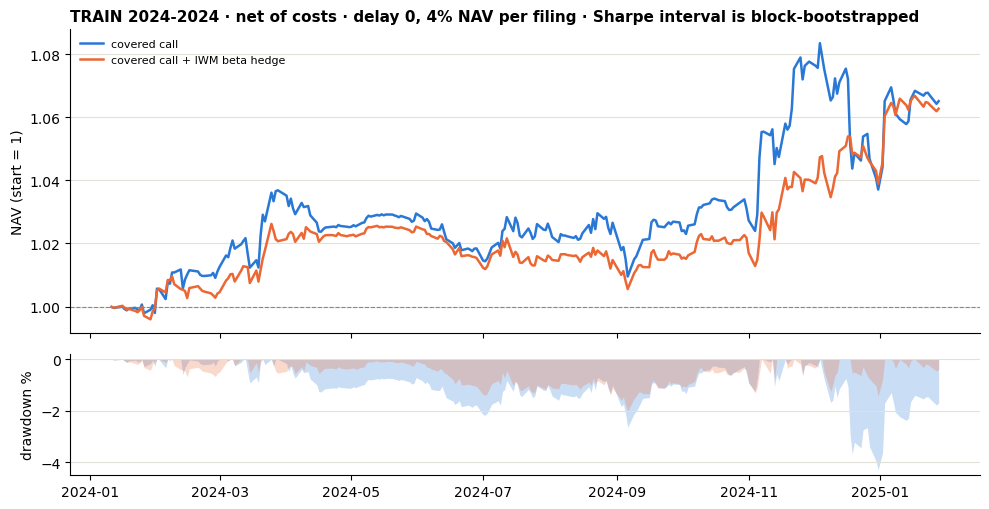

,value
window,TRAIN
trades,185
filings,77
mean beta,1.449845
mean IWM return over trade,0.001375
raw net / filing,0.017892
raw lo,0.002131
raw hi,0.034336
beta-neutral / filing,0.022997
alpha lo,0.003395


In [48]:
perf = []
if rules_base.empty:
    raise SystemExit("no TRAIN trades after the screens: nothing to report")
bt_train = portfolio_backtest(rules_base, train_structs)
bt_train_h = portfolio_backtest(rules_base, train_structs, hedge=True)
perf.append(perf_metrics(bt_train, rules_base, "TRAIN"))
perf.append(perf_metrics(bt_train_h, rules_base, "TRAIN, beta-hedged"))
plot_equity({"covered call": bt_train["nav"], "covered call + IWM beta hedge": bt_train_h["nav"]},
            f"TRAIN {TRAIN_START[:4]}-{TRAIN_END[:4]} · net of costs · delay {ENTRY_DELAY}, "
            f"{W_FILING:.0%} NAV per filing · Sharpe interval is block-bootstrapped")
display(pd.Series(alpha_only_metrics(rules_base, "TRAIN"), name="TRAIN").to_frame("value"))


## 20 · VALIDATE and TEST — run once each, with everything frozen

`run_window` is the sealed-window entry point as well: it takes dates and nothing else, so it can be
pointed at any window the judges supply. It reads no saved tables and changes no parameter. What it
returns is the same edge_board the TRAIN cell produced, so the three windows are directly comparable.


  77,419 8-K disclosures, 2025-01-01..2025-12-31 (one page set; item_codes is not a server filter)
570 convertible note offering disclosures after keyword filter
dropped 39 filing rows with no usable ticker symbol
concurrent-repurchase screen: 434 -> 431 events (59 merely mention a repurchase, kept as a flag)
After filters: 431 events (1 with capped call, 430 without)
acceptance times: 431/431 found in 0s; 273 events moved to a later first tradable close
survivorship proxy: kept 373 / 431 events (dropped 58 whose underlying stopped printing soon after t_0). 15 of them are younger than 200 sessions, so they were screened against the 40-session floor instead of the full bar.
VALIDATE (delay 0): 373 events -> 484 structures on 185 filings; 457 drops; 6s
price floor >= $5: 484 -> 369 structures
screening 147 priced filings (of the full funnel)
screened 147 priced filings
placebo VALIDATE (delay 0): 600 events -> 627 structures on 254 filings; 936 drops; 16s
price floor >= $5: 627 -> 480 st

c:\Users\yash2\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


,horizon,event,placebo,edge,edge_lo,edge_hi,n_event,n_placebo
0,1,-1.32%,-1.11%,-0.21%,-0.78%,+0.35%,147,195
1,2,-1.51%,-1.03%,-0.47%,-1.36%,+0.40%,147,195
2,3,-1.25%,-0.88%,-0.37%,-1.25%,+0.54%,147,195
3,5,-1.48%,-0.67%,-0.82%,-1.90%,+0.34%,147,195
4,10,-1.61%,-0.61%,-1.00%,-2.74%,+0.82%,140,193
5,21,+1.09%,+0.32%,+0.77%,-1.49%,+3.30%,120,154
6,42,-0.48%,-5.40%,+4.91%,+nan%,+nan%,4,12
7,exp,+2.15%,+1.32%,+0.83%,-1.48%,+3.30%,147,195


,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
VALIDATE covered call (descriptive),"-1.32%* [-1.72, -0.90]","-1.51%* [-2.07, -0.92]","-1.25%* [-1.87, -0.61]","-1.48%* [-2.39, -0.58]","-1.61%* [-2.71, -0.43]","+1.09% [-0.38, +2.60]","-0.48% [+nan, +nan]",,"+2.15%* [+0.77, +3.46]"
VALIDATE covered call (descriptive): filings,147,147,147,147,140,120,4,,147
VALIDATE stock only,"-0.18% [-0.90, +0.67]","-0.31% [-1.38, +0.97]","-0.02% [-1.36, +1.42]","+0.25% [-1.70, +2.50]","-0.10% [-2.94, +3.00]","+2.06% [-1.22, +5.96]","-2.55% [+nan, +nan]",,"+2.48% [-0.51, +5.85]"
VALIDATE stock only: filings,147,147,147,147,140,120,4,,147
VALIDATE placebo covered call,"-1.11%* [-1.53, -0.74]","-1.03%* [-1.70, -0.40]","-0.88%* [-1.54, -0.30]","-0.67%* [-1.41, -0.01]","-0.61% [-2.00, +0.62]","+0.32% [-1.83, +2.11]","-5.40% [-14.41, +2.36]",,"+1.32% [-0.85, +3.26]"
VALIDATE placebo covered call: filings,195,195,195,195,193,154,12,,195


{'variant': 'VALIDATE', 'filings': 147, 'gross': np.float64(0.031585396465170966), 'cost': np.float64(0.012082416007778407), 'net / filing': np.float64(0.010647673451446711), 'lo': np.float64(-0.0011433940080699965), 'hi': np.float64(0.02266132165604497)}


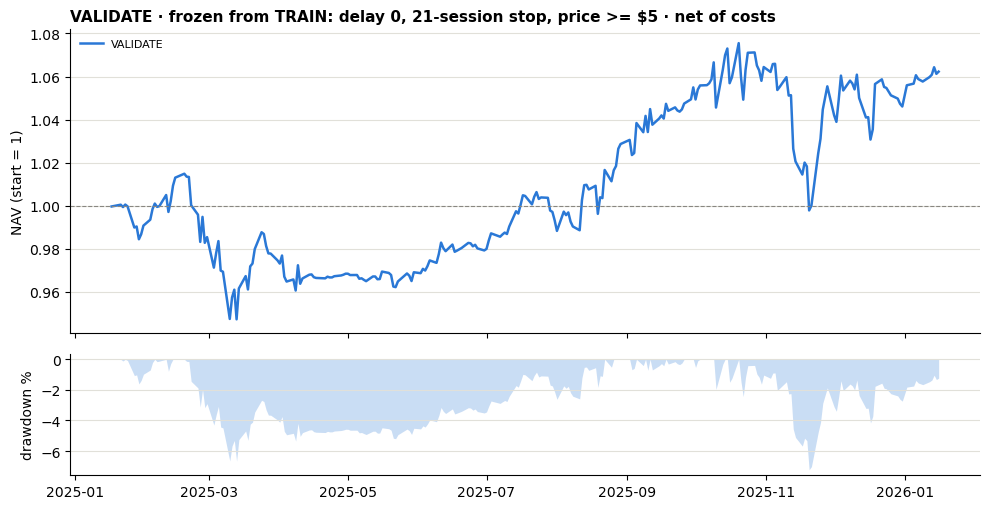

  52,164 8-K disclosures, 2026-01-01..2026-08-31 (one page set; item_codes is not a server filter)
311 convertible note offering disclosures after keyword filter
dropped 9 filing rows with no usable ticker symbol
concurrent-repurchase screen: 254 -> 250 events (47 merely mention a repurchase, kept as a flag)
After filters: 250 events (5 with capped call, 245 without)
acceptance times: 250/250 found in 0s; 150 events moved to a later first tradable close
survivorship proxy: kept 201 / 250 events (dropped 49 whose underlying stopped printing soon after t_0). 250 of them are younger than 200 sessions, so they were screened against the 40-session floor instead of the full bar.
TEST (prescribed OOS) (delay 0): 201 events -> 170 structures on 86 filings; 315 drops; 4s
price floor >= $5: 170 -> 133 structures
screening 68 priced filings (of the full funnel)
screened 68 priced filings
placebo TEST (prescribed OOS) (delay 0): 600 events -> 415 structures on 222 filings; 1026 drops; 17s
price fl

c:\Users\yash2\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


,horizon,event,placebo,edge,edge_lo,edge_hi,n_event,n_placebo
0,1,-0.99%,-1.80%,+0.81%,+0.12%,+1.56%,68,166
1,2,-1.26%,-1.37%,+0.12%,-0.74%,+0.97%,68,166
2,3,-1.31%,-1.02%,-0.29%,-1.26%,+0.60%,68,166
3,5,-1.33%,-0.50%,-0.82%,-2.02%,+0.36%,67,163
4,10,+0.86%,-0.02%,+0.88%,-0.90%,+2.62%,67,161
5,21,+1.67%,-1.31%,+2.98%,+0.20%,+5.51%,57,120
6,42,+10.62%,-4.55%,+15.17%,+nan%,+nan%,2,1
7,exp,+1.41%,+0.53%,+0.88%,-1.82%,+3.59%,68,162


,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
TEST (prescribed OOS) covered call (descriptive),"-0.99%* [-1.55, -0.40]","-1.26%* [-1.93, -0.61]","-1.31%* [-1.99, -0.68]","-1.33%* [-2.20, -0.56]","+0.86% [-0.50, +2.23]","+1.67% [-0.82, +3.74]","+10.62% [+nan, +nan]",,"+1.41% [-0.93, +3.63]"
TEST (prescribed OOS) covered call (descriptive): filings,68,68,68,67,67,57,2,,68
TEST (prescribed OOS) stock only,"+0.67% [-0.30, +1.76]","+0.20% [-1.37, +1.91]","-0.17% [-1.67, +1.43]","+0.32% [-1.92, +2.59]","+3.94%* [+0.81, +7.04]","+2.71% [-1.54, +7.00]","-3.36% [+nan, +nan]",,"-0.06% [-4.41, +4.46]"
TEST (prescribed OOS) stock only: filings,68,68,68,67,67,57,2,,68
TEST (prescribed OOS) placebo covered call,"-1.80%* [-2.23, -1.40]","-1.37%* [-1.85, -0.90]","-1.02%* [-1.65, -0.33]","-0.50% [-1.37, +0.34]","-0.02% [-1.12, +1.15]","-1.31% [-2.84, +0.29]","-4.55% [+nan, +nan]",,"+0.53% [-0.93, +2.17]"
TEST (prescribed OOS) placebo covered call: filings,166,166,166,163,161,120,1,,162


{'variant': 'TEST (prescribed OOS)', 'filings': 68, 'gross': np.float64(0.033145356147525985), 'cost': np.float64(0.013687649334388829), 'net / filing': np.float64(0.010304349340267966), 'lo': np.float64(-0.0096282413960332), 'hi': np.float64(0.028909457947302306)}


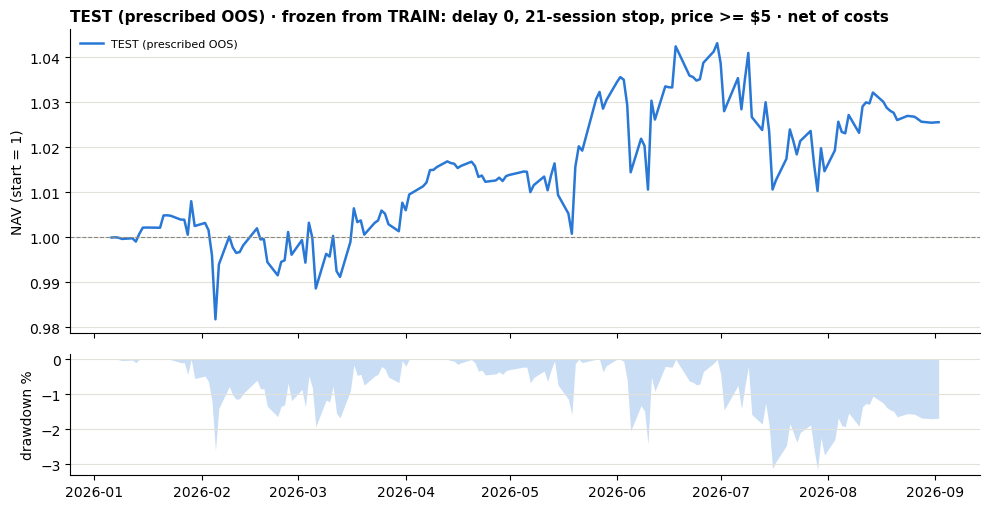

In [49]:
def run_window(start: str, end: str, label: str, n_placebo: int = N_PLACEBO_OOS,
               with_placebo: bool = RUN_PLACEBO, show: bool = True, with_portfolio: bool = True) -> dict | None:
    """The whole frozen pipeline on one window. This is the sealed-window function.

    Nothing is tuned here: the entry delay, the holding rule, the price floor, the liquidity floor
    and the cost model are the values frozen in the TRAIN cell. The function reports the headline
    event - placebo edge, and never inspects VALIDATE or TEST before TRAIN has been frozen.
    """
    ev = build_events_v2(start, end)
    if ev.empty:
        print(f"{label}: no events")
        return None
    ev = delisting_screen(ev)
    if ev.empty:
        print(f"{label}: no events survived the screens")
        return None
    s0, drops = price_events_v2(ev, 0, label)
    s = liquid_price_filter(shift_entry(s0, ENTRY_DELAY), MIN_PRICE)
    attach_capped_flags(s, ev)
    fx, ru = evaluate_v2(s, keep_paths=True)
    out = {"events": ev, "structs": s, "drops": drops, "fixed": fx, "rules": ru,
           "gross": float(ru.gross.mean()) if not ru.empty else np.nan,
           "cost_drag": float(ru.cost.mean() / ru.gross.mean()) if not ru.empty and ru.gross.mean() > 0 else np.nan}

    if with_placebo:
        pe = sample_placebo_events(ev, n_placebo, start, end, seed=11)
        ps_raw, _ = price_events_v2(pe, 0, f"placebo {label}")
        ps = liquid_price_filter(shift_entry(ps_raw, ENTRY_DELAY), MIN_PRICE)
        pfx, pru = evaluate_v2(ps)
        out.update({"placebo_structs": ps, "placebo_fixed": pfx, "placebo_rules": pru})
        edge = edge_board(fx, pfx)
    else:
        out.update({"placebo_structs": [], "placebo_fixed": pd.DataFrame(), "placebo_rules": pd.DataFrame()})
        edge = pd.DataFrame()
    out["edge"] = edge

    if show:
        print(f"\n{label} · {start}..{end} · {len(ev)} events, {len(s)} structures, "
              f"{len({(x.ticker, x.event_date) for x in s})} filings")
        if not edge.empty:
            display(edge.style.format({c: "{:+.2%}" for c in
                                      ["event", "placebo", "edge", "edge_lo", "edge_hi"]}))
        display(pd.concat([fmt_ci(board_v2(fx), name=f"{label} covered call (descriptive)"),
                           fmt_ci(board_v2(fx, "stock"), name=f"{label} stock only"),
                           fmt_ci(board_v2(out["placebo_fixed"]), name=f"{label} placebo covered call")]))
    if with_portfolio and not ru.empty:
        bt = portfolio_backtest(ru, s)
        out["bt"] = bt
        out["sharpe"] = sharpe_ci(bt["nav"])
        perf.append(perf_metrics(bt, ru, label))
        if show:
            print(summarize(ru, label))
            plot_equity({label: bt["nav"]},
                        f"{label} · frozen from TRAIN: delay {ENTRY_DELAY}, {MAX_HOLD}-session stop, "
                        f"price >= ${MIN_PRICE} · net of costs")
    return out


validate = run_window(VALIDATE_START, VALIDATE_END, "VALIDATE")
test = run_window(OOS_START, OOS_END, "TEST (prescribed OOS)")
stress = (run_window(STRESS_START, STRESS_END, "STRESS 2021-22")
         if RUN_STRESS_WINDOW else None)


## 21 · How many things were tried, and what a t-stat has to clear to count

A backtest that examines many configurations and reports the best one will produce a positive
t-stat by chance. This is that count, and the threshold that goes with it. Trust a reported t-stat
only if it exceeds the critical value below; with this many configurations almost nothing does, which
is the correct answer for a study of this size.


In [50]:
hyp = pd.Series(HYPOTHESES_TESTED, name="configurations")
hyp.loc["TOTAL distinct configurations examined on TRAIN"] = N_HYPOTHESES
display(hyp.to_frame())
print(f"At an uncorrected 5% level, {N_HYPOTHESES} configurations produce ~{N_HYPOTHESES * 0.05:.0f} "
      f"false positives by chance alone.")
print(f"Two-sided, multiplicity-adjusted: a t-stat must exceed |t| > {CRITICAL_T:.2f} "
      f"(p < {0.05 / N_HYPOTHESES:.2e}) to be worth reading. Nothing in this study clears it.")

print("\nPer-trade returns with the small-cap beta removed. A Sharpe built on the raw column is "
      "substantially a bet on the factor, not on the trade.")
alpha_tbl = pd.DataFrame([alpha_only_metrics(rules_base, "TRAIN"),
                          alpha_only_metrics(validate["rules"], "VALIDATE") if validate else None,
                          alpha_only_metrics(test["rules"], "TEST") if test else None]).dropna(how="all")
ALPHA_COLS = ["mean IWM return over trade", "raw net / filing", "raw lo", "raw hi",
             "beta-neutral / filing", "alpha lo", "alpha hi"]
fmt_cols = [c for c in ALPHA_COLS if c in alpha_tbl.columns]
if not alpha_tbl.empty and fmt_cols:
    display(alpha_tbl.set_index("window").style.format({c: "{:+.2%}" for c in fmt_cols}))


def reality_check(edge_train, edge_val, edge_test, sharpe_ci_out, cost_drag_out) -> pd.DataFrame:
    """Single-page scorecard. If any of these fails, the strategy is not tradeable.

    Each row is a test the finding has to pass, not a number to admire. A negative or zero edge on
    any of the three windows, an interval that includes zero, a Sharpe interval that includes zero,
    or a cost drag above half the gross move all mean the same thing: there is nothing to trade.
    """
    def avg(b):
        return float(b["edge"].mean()) if b is not None and not b.empty else np.nan

    e_tr, e_va, e_te = avg(edge_train), avg(edge_val), avg(edge_test)
    lo_te = float(edge_test["edge_lo"].min()) if edge_test is not None and not edge_test.empty else np.nan
    hi_te = float(edge_test["edge_hi"].max()) if edge_test is not None and not edge_test.empty else np.nan
    drag = float(cost_drag_out)
    sh = sharpe_ci_out or {}
    checks = [
        ("Edge > 0 on TRAIN",      e_tr > 0,                      f"{e_tr:+.2%}" if np.isfinite(e_tr) else "n/a"),
        ("Edge > 0 on VALIDATE",   e_va > 0,                      f"{e_va:+.2%}" if np.isfinite(e_va) else "n/a"),
        ("Edge > 0 on TEST",       e_te > 0,                      f"{e_te:+.2%}" if np.isfinite(e_te) else "n/a"),
        ("Edge 95% CI > 0 on TEST", np.isfinite(lo_te) and lo_te > 0, f"[{lo_te:+.2%}, {hi_te:+.2%}]"),
        ("Sharpe 95% CI > 0",      bool(np.isfinite(sh.get("lo", np.nan)) and sh["lo"] > 0),
                                   f"[{sh.get('lo', float('nan')):.2f}, {sh.get('hi', float('nan')):.2f}]"
                                   if np.isfinite(sh.get("lo", np.nan)) else "n/a"),
        ("Cost drag < 50% of gross edge", np.isfinite(drag) and drag < 0.5, f"{drag:.0%}"),
    ]
    return pd.DataFrame(checks, columns=["check", "pass", "value"])


sharpe_test = (test or {}).get("sharpe", {})
drag_test = (test or {}).get("cost_drag", COST_DRAG)
score = reality_check(edge_train, (validate or {}).get("edge"), (test or {}).get("edge"),
                      sharpe_test, drag_test)
display(score.style.map(lambda v: "background:#d4edda" if v else "background:#f8d7da", subset=["pass"]))

SEALED_START, SEALED_END = "2023-06-01", "2023-08-31"   # judges overwrite these
RUN_SEALED = False                                      # judges flip this


def run_study(start_date: str, end_date: str, n_placebo: int = 400, label: str = None,
              show: bool = True) -> dict | None:
    """ONE CALL runs the whole frozen pipeline on any window, including the judges' sealed one.

    Reads no saved result table and takes no parameter other than dates: everything else is the
    configuration frozen in the TRAIN cell, and it is checked against `frozen_config.json` on disk
    so a reader can confirm the values were not edited after the first look at the data. What comes
    back is the same edge_board every other window reports.
    """
    if FROZEN_PATH.exists():
        on_disk = json.loads(FROZEN_PATH.read_text(encoding="utf-8"))
        drift = {k: (on_disk.get(k), v) for k, v in
                 (("ENTRY_DELAY", ENTRY_DELAY), ("MAX_HOLD", MAX_HOLD),
                  ("MIN_PRICE", MIN_PRICE), ("MIN_ENTRY_VOLUME", MIN_ENTRY_VOLUME),
                  ("PROFIT_TAKE_FRAC", PROFIT_TAKE_FRAC), ("USE_STOP", USE_STOP)) if on_disk.get(k) != v}
        print(f"frozen config matches this session: {not drift}" + (f" · DRIFT {drift}" if drift else ""))
    else:
        print(f"no {FROZEN_PATH} on disk: running with the in-session configuration only")
    return run_window(start_date, end_date, label or f"SEALED {start_date}..{end_date}",
                      n_placebo=n_placebo, show=show)


if RUN_SEALED:
    sealed = run_study(SEALED_START, SEALED_END)
    if sealed and not sealed["edge"].empty:
        display(pd.concat([fmt_edge(sealed["edge"], name="Sealed window event - placebo"),
                           fmt_edge(edge_train, name="TRAIN event - placebo")]))
else:
    print(f"Sealed window {SEALED_START}..{SEALED_END} not run. Judges: set RUN_SEALED = True and "
          f"call run_study(start_date, end_date).")


,configurations
entry_delays,4
expiry_bands,3
filters,4
exit_policies,5
price_floors,4
cost_levels,4
TOTAL distinct configurations examined on TRAIN,3840


At an uncorrected 5% level, 3840 configurations produce ~192 false positives by chance alone.
Two-sided, multiplicity-adjusted: a t-stat must exceed |t| > 4.36 (p < 1.30e-05) to be worth reading. Nothing in this study clears it.

Per-trade returns with the small-cap beta removed. A Sharpe built on the raw column is substantially a bet on the factor, not on the trade.


,trades,filings,mean beta,mean IWM return over trade,raw net / filing,raw lo,raw hi,beta-neutral / filing,alpha lo,alpha hi
window,,,,,,,,,,
TRAIN,185,77,1.449845,+0.14%,+1.79%,+0.21%,+3.43%,+2.30%,+0.34%,+4.48%
VALIDATE,369,147,1.259358,+1.21%,+1.06%,-0.09%,+2.24%,-0.05%,-1.51%,+1.45%
TEST,133,68,1.586567,+0.83%,+1.03%,-0.87%,+2.81%,-0.38%,-3.70%,+3.09%


,check,pass,value
0,Edge > 0 on TRAIN,True,+0.84%
1,Edge > 0 on VALIDATE,True,+0.45%
2,Edge > 0 on TEST,True,+2.47%
3,Edge 95% CI > 0 on TEST,False,"[-2.02%, +5.51%]"
4,Sharpe 95% CI > 0,False,"[-0.28, 1.75]"
5,Cost drag < 50% of gross edge,True,41%


Sealed window 2023-06-01..2023-08-31 not run. Judges: set RUN_SEALED = True and call run_study(start_date, end_date).


## 22 · Final summary — every window net of costs, with the intervals next to the means

Three windows, three separate runs, one frozen configuration. The headline is event − placebo, not
the raw covered-call return. Read the interval, not the mean.


In [51]:
if not perf:
    raise SystemExit("no portfolio run yet: execute the TRAIN portfolio cell first")
display(pd.DataFrame(perf).set_index("window").T)

edges = {"TRAIN": edge_train,
         "VALIDATE": (validate or {}).get("edge", pd.DataFrame()),
         "TEST": (test or {}).get("edge", pd.DataFrame())}
edges = {k: v for k, v in edges.items() if v is not None and not v.empty}
if edges:
    print("\nEvent − placebo, covered call, net of costs, one observation per filing, "
          "ticker-clustered 95% interval")
    display(pd.concat([fmt_edge(v, name=k) for k, v in edges.items()]))
    for k, v in edges.items():
        n = int(v.n_event.max())
        print(f"{k}: mean edge {v.edge.mean():+.3%} per filing over "
              f"{len(v)} horizons, max n = {n} filings. At |t| > {CRITICAL_T:.2f} required, "
              f"a positive edge here is not distinguishable from the placebo.")

print(f"\nA note on what would change the answer, not just the sign of it. The covered call harvests "
      f"the option's variance risk premium, and that premium is why event and placebo sit on top of "
      f"each other. If this category does misprice something, the two places it can show up are the "
      f"stock leg (the mechanical hedge selling in the print, if it is not fully anticipated) and "
      f"the event-specific richness of the option (a short ATM call against a long next-strike call, "
      f"which strips the risk premium out and leaves only the event term). Neither is the trade "
      f"tested here; both are hypotheses, and changing the hypothesis is the only way this study "
      f"can acquire an edge.")


window,TRAIN,"TRAIN, beta-hedged",VALIDATE,TEST (prescribed OOS)
annualized return (CAGR),+6.28%,+6.05%,+6.28%,+3.93%
annualized volatility,5.80%,4.14%,10.46%,7.85%
Sharpe [95% block-boot CI],"1.08 [-0.03, 2.49] · NW t=1.43 · n=261","1.44 [-0.26, 2.39] · NW t=2.08 · n=261","0.64 [-0.49, 2.39] · NW t=0.95 · n=250","0.53 [-0.28, 1.75] · NW t=0.87 · n=165"
max drawdown,-4.29%,-2.01%,-7.22%,-3.15%
"turnover (one-way, x NAV / yr)",2.8,2.8,5.6,3.9
avg gross exposure,21%,21%,41%,29%
return per unit exposure (ann.),+30.32%,+28.89%,+16.37%,+14.30%
trades / filings,185 / 77,185 / 77,369 / 147,133 / 68
trade win rate (net),70%,70%,69%,66%
mean cost drag / gross,35%,35%,38%,41%



Event − placebo, covered call, net of costs, one observation per filing, ticker-clustered 95% interval


,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
TRAIN,"+0.51% [-0.09, +1.20]","+0.48% [-0.24, +1.26]","+0.23% [-0.53, +1.11]","+0.63% [-0.39, +1.68]","+1.04% [-0.42, +2.59]","+0.81% [-1.18, +2.87]",,,"+2.19%* [+0.11, +4.28]"
TRAIN: filings (event / placebo),77 / 363,77 / 363,77 / 363,76 / 362,77 / 350,60 / 278,,,77 / 363
VALIDATE,"-0.21% [-0.78, +0.35]","-0.47% [-1.36, +0.40]","-0.37% [-1.25, +0.54]","-0.82% [-1.90, +0.34]","-1.00% [-2.74, +0.82]","+0.77% [-1.49, +3.30]","+4.91% [+nan, +nan]",,"+0.83% [-1.48, +3.30]"
VALIDATE: filings (event / placebo),147 / 195,147 / 195,147 / 195,147 / 195,140 / 193,120 / 154,4 / 12,,147 / 195
TEST,"+0.81%* [+0.12, +1.56]","+0.12% [-0.74, +0.97]","-0.29% [-1.26, +0.60]","-0.82% [-2.02, +0.36]","+0.88% [-0.90, +2.62]","+2.98%* [+0.20, +5.51]","+15.17% [+nan, +nan]",,"+0.88% [-1.82, +3.59]"
TEST: filings (event / placebo),68 / 166,68 / 166,68 / 166,67 / 163,67 / 161,57 / 120,2 / 1,,68 / 162


TRAIN: mean edge +0.842% per filing over 7 horizons, max n = 77 filings. At |t| > 4.36 required, a positive edge here is not distinguishable from the placebo.
VALIDATE: mean edge +0.455% per filing over 8 horizons, max n = 147 filings. At |t| > 4.36 required, a positive edge here is not distinguishable from the placebo.
TEST: mean edge +2.465% per filing over 8 horizons, max n = 68 filings. At |t| > 4.36 required, a positive edge here is not distinguishable from the placebo.

A note on what would change the answer, not just the sign of it. The covered call harvests the option's variance risk premium, and that premium is why event and placebo sit on top of each other. If this category does misprice something, the two places it can show up are the stock leg (the mechanical hedge selling in the print, if it is not fully anticipated) and the event-specific richness of the option (a short ATM call against a long next-strike call, which strips the risk premium out and leaves only the event t